<a href="https://colab.research.google.com/github/KashyapKrishnan09/SolarModel/blob/main/SolarPanel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Maintenance Alert Logic: Rule-Based Approach

We will define a rule-based system to trigger maintenance alerts. The primary indicators for potential issues will be:

1.  **Significant drop in Actual DC Power compared to Ideal DC Power**: If the `DC_POWER` is considerably lower than the `IDEAL_DC_POWER` (e.g., less than 80% of ideal), it could indicate an underperformance issue.
2.  **Low Inverter Efficiency**: If the `INVERTER_EFFICIENCY` falls below a certain threshold (e.g., 0.90 or 90%), it might signal an inverter malfunction or degradation.

We will create a function that applies these rules to each data point and flags potential maintenance alerts.

In [1]:
def generate_maintenance_alerts(df, ideal_dc_power_threshold=0.8, inverter_efficiency_threshold=0.90):
    """
    Generates maintenance alerts based on DC Power deviation from ideal and inverter efficiency.

    Args:
        df (pd.DataFrame): The DataFrame containing 'DC_POWER', 'IDEAL_DC_POWER', and 'INVERTER_EFFICIENCY'.
        ideal_dc_power_threshold (float): The threshold for DC_POWER / IDEAL_DC_POWER ratio to trigger an alert.
                                        An alert is triggered if DC_POWER < ideal_dc_power_threshold * IDEAL_DC_POWER.
        inverter_efficiency_threshold (float): The threshold for INVERTER_EFFICIENCY to trigger an alert.
                                             An alert is triggered if INVERTER_EFFICIENCY < inverter_efficiency_threshold.

    Returns:
        pd.DataFrame: The DataFrame with an 'ALERT' column indicating maintenance alerts.
    """
    df_alerts = df.copy()
    df_alerts['ALERT'] = False

    # Rule 1: DC Power significantly lower than Ideal DC Power
    # Only apply this rule when IDEAL_DC_POWER is positive (i.e., when there is irradiation)
    condition_dc_power_drop = (df_alerts['IDEAL_DC_POWER'] > 0) & \
                              (df_alerts['DC_POWER'] < ideal_dc_power_threshold * df_alerts['IDEAL_DC_POWER'])
    df_alerts.loc[condition_dc_power_drop, 'ALERT'] = True

    # Rule 2: Low Inverter Efficiency
    # Only apply this rule when DC_POWER is positive (i.e., when inverters are active)
    condition_low_efficiency = (df_alerts['DC_POWER'] > 0) & \
                               (df_alerts['INVERTER_EFFICIENCY'] < inverter_efficiency_threshold)
    df_alerts.loc[condition_low_efficiency, 'ALERT'] = True

    return df_alerts

# Apply the alert logic to Plant 1 data
merged_plant1_data_alerts = generate_maintenance_alerts(merged_plant1_data)
print("\n--- Plant 1 Alerts (First 10) ---")
display(merged_plant1_data_alerts[merged_plant1_data_alerts['ALERT']].head(10))
print(f"Total alerts for Plant 1: {merged_plant1_data_alerts['ALERT'].sum()}")

# Apply the alert logic to Plant 2 data
merged_plant2_data_alerts = generate_maintenance_alerts(merged_plant2_data)
print("\n--- Plant 2 Alerts (First 10) ---")
display(merged_plant2_data_alerts[merged_plant2_data_alerts['ALERT']].head(10))
print(f"Total alerts for Plant 2: {merged_plant2_data_alerts['ALERT'].sum()}")

NameError: name 'merged_plant1_data' is not defined

### Maintenance Alert Logic: Machine Learning (ML) Based Approach

To more robustly detect performance drops, especially considering factors like ambient temperature as requested, we will use our previously trained linear regression models. These models predict an *expected* `DC_POWER` based on `IRRADIATION`, `AMBIENT_TEMPERATURE`, and `MODULE_TEMPERATURE`.

Our ML-based alert system will operate as follows:

1.  **Predict Expected DC Power**: For each data point, we will use the appropriate linear regression model (`model_plant1` or `model_plant2`) to predict the `DC_POWER` based on its environmental conditions.
2.  **Compare Actual vs. Predicted**: An alert will be triggered if the actual `DC_POWER` falls below a certain percentage of this `predicted_DC_POWER`. This directly addresses the scenario where 'energy output drops for the same ambient temperature'.

This approach allows for a more nuanced and context-aware alert system than a simple rule-based threshold.

In [8]:
print('Executing prerequisite cells...')
get_ipython().run_cell_helper('d94941ec') # Data cleaning and loading
get_ipython().run_cell_helper('f0b2da74') # Merging data and calculating inverter efficiency
get_ipython().run_cell_helper('16c127ea') # Calculating ideal DC power
get_ipython().run_cell_helper('0f75c019') # Simulating noisy weather data
get_ipython().run_cell_helper('2996764d') # Preparing data for linear regression models
get_ipython().run_cell_helper('65de977e') # Training and evaluating linear regression models
print('Prerequisite cells executed. You can now run cell a7ac8577 and subsequent cells.')

Executing prerequisite cells...


AttributeError: 'Shell' object has no attribute 'run_cell_helper'

In [11]:
print('--- Executing all prerequisite setup steps ---')

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Code from cell d94941ec (Data Cleaning and Loading) ---
print('\n--- Starting Data Cleaning and Loading ---')
plant1_generation_path = '/content/Plant_1_Generation_Data.csv'
plant2_generation_path = '/content/Plant_2_Generation_Data.csv'
plant1_weather_path = '/content/Plant_1_Weather_Sensor_Data.csv'
plant2_weather_path = '/content/Plant_2_Weather_Sensor_Data.csv'

print('Loading dataframes for cleaning...')

try:
    df_gen1 = pd.read_csv(plant1_generation_path)
    df_gen1['DATE_TIME'] = pd.to_datetime(df_gen1['DATE_TIME'], errors='coerce', dayfirst=True)
    df_gen1.dropna(subset=['DATE_TIME'], inplace=True)
    print(f'Loaded {plant1_generation_path} with {len(df_gen1)} rows.')
except FileNotFoundError as e:
    print(f'Error loading Plant 1 Generation data: {e}. Initializing as empty DataFrame.')
    df_gen1 = pd.DataFrame()

try:
    df_weather1 = pd.read_csv(plant1_weather_path)
    df_weather1['DATE_TIME'] = pd.to_datetime(df_weather1['DATE_TIME'], errors='coerce')
    df_weather1.dropna(subset=['DATE_TIME'], inplace=True)
    print(f'Loaded {plant1_weather_path} with {len(df_weather1)} rows.')
except FileNotFoundError as e:
    print(f'Error loading Plant 1 Weather data: {e}. Initializing as empty DataFrame.')
    df_weather1 = pd.DataFrame()

try:
    df_gen2 = pd.read_csv(plant2_generation_path)
    df_gen2['DATE_TIME'] = pd.to_datetime(df_gen2['DATE_TIME'], errors='coerce')
    df_gen2.dropna(subset=['DATE_TIME'], inplace=True)
    print(f'Loaded {plant2_generation_path} with {len(df_gen2)} rows.')
except FileNotFoundError as e:
    print(f'Error loading Plant 2 Generation data: {e}. Initializing as empty DataFrame.')
    df_gen2 = pd.DataFrame()

try:
    df_weather2 = pd.read_csv(plant2_weather_path)
    df_weather2['DATE_TIME'] = pd.to_datetime(df_weather2['DATE_TIME'], errors='coerce')
    df_weather2.dropna(subset=['DATE_TIME'], inplace=True)
    print(f'Loaded {plant2_weather_path} with {len(df_weather2)} rows.')
except FileNotFoundError as e:
    print(f'Error loading Plant 2 Weather data: {e}. Initializing as empty DataFrame.')
    df_weather2 = pd.DataFrame()

print('Dataframe loading complete.')

def clean_dataframe(df, file_name):
    print(f'\n--- Cleaning DataFrame: {file_name} ---')
    initial_nulls = df.isnull().sum()
    print('Initial missing values per column:\n', initial_nulls[initial_nulls > 0])

    numeric_cols = df.select_dtypes(include=np.number).columns

    if not numeric_cols.empty:
        df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit_direction='both')
        df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')

    final_nulls = df.isnull().sum()
    print('Final missing values per column after cleaning:\n', final_nulls[final_nulls > 0])
    if final_nulls.sum() == 0:
        print('All numerical missing values handled.')
    else:
        print('Some non-numerical missing values might remain or could not be filled.')

    return df

if not df_gen1.empty:
    df_gen1 = clean_dataframe(df_gen1.copy(), 'Plant_1_Generation_Data.csv')
if not df_weather1.empty:
    df_weather1 = clean_dataframe(df_weather1.copy(), 'Plant_1_Weather_Sensor_Data.csv')
if not df_gen2.empty:
    df_gen2 = clean_dataframe(df_gen2.copy(), 'Plant_2_Generation_Data.csv')
if not df_weather2.empty:
    df_weather2 = clean_dataframe(df_weather2.copy(), 'Plant_2_Weather_Sensor_Data.csv')

print('\nData cleaning complete. Dataframes are now cleaned.')

# --- Code from cell f0b2da74 (Merge data and calculate efficiency) ---
print('\n--- Starting Data Merging and Efficiency Calculation ---')
merged_plant1_data = pd.merge(
    df_gen1[['DATE_TIME', 'PLANT_ID', 'DC_POWER', 'AC_POWER', 'TOTAL_YIELD']],
    df_weather1[['DATE_TIME', 'PLANT_ID', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']],
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)
merged_plant1_data['INVERTER_EFFICIENCY'] = np.where(
    merged_plant1_data['DC_POWER'] > 0,
    merged_plant1_data['AC_POWER'] / merged_plant1_data['DC_POWER'],
    0
).clip(max=1.0)

merged_plant2_data = pd.merge(
    df_gen2[['DATE_TIME', 'PLANT_ID', 'DC_POWER', 'AC_POWER', 'TOTAL_YIELD']],
    df_weather2[['DATE_TIME', 'PLANT_ID', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']],
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)
merged_plant2_data['INVERTER_EFFICIENCY'] = np.where(
    merged_plant2_data['DC_POWER'] > 0,
    merged_plant2_data['AC_POWER'] / merged_plant2_data['DC_POWER'],
    0
).clip(max=1.0)
print('Data merging and efficiency calculation complete.')

# --- Code from cell 16c127ea (Calculate Ideal DC Power) ---
print('\n--- Starting Ideal DC Power Calculation ---')
plant1_power_per_irr = merged_plant1_data[
    (merged_plant1_data['IRRADIATION'] > 0) & (merged_plant1_data['DC_POWER'] > 0)
].copy()

if not plant1_power_per_irr.empty:
    plant1_power_per_irr['DC_POWER_PER_IRRADIATION'] = plant1_power_per_irr['DC_POWER'] / plant1_power_per_irr['IRRADIATION']
    max_dc_per_irr_plant1 = plant1_power_per_irr['DC_POWER_PER_IRRADIATION'].max()
    merged_plant1_data['IDEAL_DC_POWER'] = merged_plant1_data['IRRADIATION'] * max_dc_per_irr_plant1
else:
    merged_plant1_data['IDEAL_DC_POWER'] = 0

plant2_power_per_irr = merged_plant2_data[
    (merged_plant2_data['IRRADIATION'] > 0) & (merged_plant2_data['DC_POWER'] > 0)
].copy()

if not plant2_power_per_irr.empty:
    plant2_power_per_irr['DC_POWER_PER_IRRADIATION'] = plant2_power_per_irr['DC_POWER'] / plant2_power_per_irr['IRRADIATION']
    max_dc_per_irr_plant2 = plant2_power_per_irr['DC_POWER_PER_IRRADIATION'].max()
    merged_plant2_data['IDEAL_DC_POWER'] = merged_plant2_data['IRRADIATION'] * max_dc_per_irr_plant2
else:
    merged_plant2_data['IDEAL_DC_POWER'] = 0
print('Ideal DC Power calculation complete.')

# --- Code from cell 0f75c019 (Simulate Noisy Weather Data) ---
print('\n--- Starting Noisy Weather Data Simulation ---')
def add_weather_noise(df, irradiation_noise_std=0.05, temp_noise_std=2.0, seed=42):
    np.random.seed(seed)
    noisy_df = df.copy()

    if 'IRRADIATION' in noisy_df.columns:
        noise = np.random.normal(0, irradiation_noise_std, size=len(noisy_df))
        noisy_df['IRRADIATION'] = noisy_df['IRRADIATION'] + noise
        noisy_df['IRRADIATION'] = noisy_df['IRRADIATION'].clip(lower=0)

    if 'AMBIENT_TEMPERATURE' in noisy_df.columns:
        noise = np.random.normal(0, temp_noise_std, size=len(noisy_df))
        noisy_df['AMBIENT_TEMPERATURE'] = noisy_df['AMBIENT_TEMPERATURE'] + noise

    if 'MODULE_TEMPERATURE' in noisy_df.columns:
        noise = np.random.normal(0, temp_noise_std, size=len(noisy_df))
        noisy_df['MODULE_TEMPERATURE'] = noisy_df['MODULE_TEMPERATURE'] + noise

    return noisy_df

noisy_plant1_data = add_weather_noise(merged_plant1_data.copy(), irradiation_noise_std=0.01, temp_noise_std=1.0)
noisy_plant1_data['INVERTER_EFFICIENCY'] = np.where(
    noisy_plant1_data['DC_POWER'] > 0,
    noisy_plant1_data['AC_POWER'] / noisy_plant1_data['DC_POWER'],
    0
).clip(max=1.0)
noisy_plant1_data['IDEAL_DC_POWER'] = noisy_plant1_data['IRRADIATION'] * max_dc_per_irr_plant1

noisy_plant2_data = add_weather_noise(merged_plant2_data.copy(), irradiation_noise_std=0.005, temp_noise_std=0.5)
noisy_plant2_data['INVERTER_EFFICIENCY'] = np.where(
    noisy_plant2_data['DC_POWER'] > 0,
    noisy_plant2_data['AC_POWER'] / noisy_plant2_data['DC_POWER'],
    0
).clip(max=1.0)
noisy_plant2_data['IDEAL_DC_POWER'] = noisy_plant2_data['IRRADIATION'] * max_dc_per_irr_plant2
print('Noisy weather data simulation complete.')

# --- Code from cell 2996764d (Prepare Data for Linear Regression Models) ---
print('\n--- Starting Data Preparation for Linear Regression Models ---')
X_plant1 = merged_plant1_data[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
y_plant1 = merged_plant1_data['DC_POWER']
X_plant1 = X_plant1.dropna() # Use a direct assignment to avoid SettingWithCopyWarning
y_plant1 = y_plant1[X_plant1.index]
X_train_plant1, X_test_plant1, y_train_plant1, y_test_plant1 = train_test_split(X_plant1, y_plant1, test_size=0.2, random_state=42)

X_plant2 = merged_plant2_data[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
y_plant2 = merged_plant2_data['DC_POWER']
X_plant2 = X_plant2.dropna() # Use a direct assignment to avoid SettingWithCopyWarning
y_plant2 = y_plant2[X_plant2.index]
X_train_plant2, X_test_plant2, y_train_plant2, y_test_plant2 = train_test_split(X_plant2, y_plant2, test_size=0.2, random_state=42)
print('Data preparation for linear regression models complete.')

# --- Code from cell 65de977e (Train and Evaluate Linear Regression Models) ---
print('\n--- Starting Linear Regression Model Training and Evaluation ---')
model_plant1 = LinearRegression()
model_plant1.fit(X_train_plant1, y_train_plant1)

y_pred_plant1 = model_plant1.predict(X_test_plant1)
mae_plant1 = mean_absolute_error(y_test_plant1, y_pred_plant1)
mse_plant1 = mean_squared_error(y_test_plant1, y_pred_plant1)
rmse_plant1 = np.sqrt(mse_plant1)
r2_plant1 = r2_score(y_test_plant1, y_pred_plant1)

print(f'Plant 1 - R-squared: {r2_plant1:.4f}')

model_plant2 = LinearRegression()
model_plant2.fit(X_train_plant2, y_train_plant2)

y_pred_plant2 = model_plant2.predict(X_test_plant2)
mae_plant2 = mean_absolute_error(y_test_plant2, y_pred_plant2)
mse_plant2 = mean_squared_error(y_test_plant2, y_pred_plant2)
rmse_plant2 = np.sqrt(mse_plant2)
r2_plant2 = r2_score(y_test_plant2, y_pred_plant2)

print(f'Plant 2 - R-squared: {r2_plant2:.4f}')
print('Linear regression model training and evaluation complete.')

print('\n--- All prerequisite setup steps executed successfully! ---')
print('You can now run cell a7ac8577 and subsequent cells.')

--- Executing all prerequisite setup steps ---

--- Starting Data Cleaning and Loading ---
Loading dataframes for cleaning...
Loaded /content/Plant_1_Generation_Data.csv with 68778 rows.
Loaded /content/Plant_1_Weather_Sensor_Data.csv with 3182 rows.
Loaded /content/Plant_2_Generation_Data.csv with 67698 rows.
Loaded /content/Plant_2_Weather_Sensor_Data.csv with 3259 rows.
Dataframe loading complete.

--- Cleaning DataFrame: Plant_1_Generation_Data.csv ---
Initial missing values per column:
 Series([], dtype: int64)
Final missing values per column after cleaning:
 Series([], dtype: int64)
All numerical missing values handled.

--- Cleaning DataFrame: Plant_1_Weather_Sensor_Data.csv ---
Initial missing values per column:
 Series([], dtype: int64)
Final missing values per column after cleaning:
 Series([], dtype: int64)
All numerical missing values handled.

--- Cleaning DataFrame: Plant_2_Generation_Data.csv ---
Initial missing values per column:
 Series([], dtype: int64)
Final missing 

/tmp/ipykernel_2788/3798395385.py:68: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_2788/3798395385.py:68: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_2788/3798395385.py:68: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_2788/3798395385.py:68: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method=

In [12]:
def generate_ml_maintenance_alerts(df, model, features, prediction_threshold_ratio=0.85):
    """
    Generates maintenance alerts based on a machine learning model's prediction of DC Power.

    Args:
        df (pd.DataFrame): The DataFrame containing 'DC_POWER' and the 'features' used by the model.
        model (sklearn.linear_model.LinearRegression): The trained linear regression model.
        features (list): A list of column names in df that correspond to the model's features.
        prediction_threshold_ratio (float): The ratio of actual DC_POWER to predicted DC_POWER.
                                        An alert is triggered if DC_POWER < prediction_threshold_ratio * predicted_DC_POWER.

    Returns:
        pd.DataFrame: The DataFrame with an 'ML_ALERT' column indicating maintenance alerts.
    """
    df_ml_alerts = df.copy()
    df_ml_alerts['ML_ALERT'] = False

    # Only make predictions where IRRADIATION is positive, as DC_POWER is 0 when no light
    active_generation_indices = df_ml_alerts[df_ml_alerts['IRRADIATION'] > 0].index

    if not active_generation_indices.empty:
        # Prepare features for prediction
        X_predict = df_ml_alerts.loc[active_generation_indices, features]

        # Predict expected DC_POWER
        df_ml_alerts.loc[active_generation_indices, 'PREDICTED_DC_POWER'] = model.predict(X_predict)

        # Rule: Actual DC_POWER significantly lower than predicted DC_POWER
        condition_ml_alert = ((df_ml_alerts['DC_POWER'] < prediction_threshold_ratio * df_ml_alerts['PREDICTED_DC_POWER']) &
                             (df_ml_alerts['DC_POWER'] > 0)) # Ensure we only alert on actual power generation drops
        df_ml_alerts.loc[condition_ml_alert, 'ML_ALERT'] = True
    else:
        df_ml_alerts['PREDICTED_DC_POWER'] = 0

    return df_ml_alerts

# Define the features used by the models
model_features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']

# --- Apply ML alert logic to Plant 1 data (original) ---
print("\n--- Plant 1 ML Alerts (Original Data) ---")
ml_alerts_original_plant1 = generate_ml_maintenance_alerts(merged_plant1_data.copy(), model_plant1, model_features)
display(ml_alerts_original_plant1[ml_alerts_original_plant1['ML_ALERT']].head(10))
print(f"Total ML alerts for original Plant 1: {ml_alerts_original_plant1['ML_ALERT'].sum()}")

# --- Apply ML alert logic to Plant 2 data (original) ---
print("\n--- Plant 2 ML Alerts (Original Data) ---")
ml_alerts_original_plant2 = generate_ml_maintenance_alerts(merged_plant2_data.copy(), model_plant2, model_features)
display(ml_alerts_original_plant2[ml_alerts_original_plant2['ML_ALERT']].head(10))
print(f"Total ML alerts for original Plant 2: {ml_alerts_original_plant2['ML_ALERT'].sum()}")

# --- Apply ML alert logic to Plant 1 data (noisy) ---
print("\n--- Plant 1 ML Alerts (Noisy Data) ---")
ml_alerts_noisy_plant1 = generate_ml_maintenance_alerts(noisy_plant1_data.copy(), model_plant1, model_features)
display(ml_alerts_noisy_plant1[ml_alerts_noisy_plant1['ML_ALERT']].head(10))
print(f"Total ML alerts for noisy Plant 1: {ml_alerts_noisy_plant1['ML_ALERT'].sum()}")

# --- Apply ML alert logic to Plant 2 data (noisy) ---
print("\n--- Plant 2 ML Alerts (Noisy Data) ---")
ml_alerts_noisy_plant2 = generate_ml_maintenance_alerts(noisy_plant2_data.copy(), model_plant2, model_features)
display(ml_alerts_noisy_plant2[ml_alerts_noisy_plant2['ML_ALERT']].head(10))
print(f"Total ML alerts for noisy Plant 2: {ml_alerts_noisy_plant2['ML_ALERT'].sum()}")


--- Plant 1 ML Alerts (Original Data) ---


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,INVERTER_EFFICIENCY,IDEAL_DC_POWER,ML_ALERT,PREDICTED_DC_POWER
510,2020-05-15 06:00:00,4135001,37.142857,3.585714,6259559.0,24.088446,22.206757,0.005887,0.096538,166.892322,True,149.026877
511,2020-05-15 06:00:00,4135001,53.500000,5.162500,6183645.0,24.088446,22.206757,0.005887,0.096495,166.892322,True,149.026877
512,2020-05-15 06:00:00,4135001,58.000000,5.585714,6987759.0,24.088446,22.206757,0.005887,0.096305,166.892322,True,149.026877
513,2020-05-15 06:00:00,4135001,58.428571,5.628571,7602960.0,24.088446,22.206757,0.005887,0.096333,166.892322,True,149.026877
514,2020-05-15 06:00:00,4135001,54.375000,5.250000,7158964.0,24.088446,22.206757,0.005887,0.096552,166.892322,True,149.026877
516,2020-05-15 06:00:00,4135001,43.857143,4.228571,7028673.0,24.088446,22.206757,0.005887,0.096417,166.892322,True,149.026877
517,2020-05-15 06:00:00,4135001,58.571429,5.671429,6522172.0,24.088446,22.206757,0.005887,0.096829,166.892322,True,149.026877
518,2020-05-15 06:00:00,4135001,24.500000,2.366667,7098099.0,24.088446,22.206757,0.005887,0.096599,166.892322,True,149.026877
519,2020-05-15 06:00:00,4135001,56.125000,5.425000,6271355.0,24.088446,22.206757,0.005887,0.096659,166.892322,True,149.026877
520,2020-05-15 06:00:00,4135001,37.000000,3.571429,6316803.0,24.088446,22.206757,0.005887,0.096525,166.892322,True,149.026877


Total ML alerts for original Plant 1: 3831

--- Plant 2 ML Alerts (Original Data) ---


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,INVERTER_EFFICIENCY,IDEAL_DC_POWER,ML_ALERT,PREDICTED_DC_POWER
528,2020-05-15 06:00:00,4136001,15.406667,14.860000,2.429012e+06,24.742787,24.07723,0.012962,0.964518,47.632343,True,32.885047
529,2020-05-15 06:00:00,4136001,14.773333,14.246667,1.215279e+09,24.742787,24.07723,0.012962,0.964350,47.632343,True,32.885047
530,2020-05-15 06:00:00,4136001,15.380000,14.840000,2.247720e+09,24.742787,24.07723,0.012962,0.964889,47.632343,True,32.885047
531,2020-05-15 06:00:00,4136001,14.973333,14.440000,1.704251e+06,24.742787,24.07723,0.012962,0.964381,47.632343,True,32.885047
532,2020-05-15 06:00:00,4136001,15.160000,14.633333,1.994153e+07,24.742787,24.07723,0.012962,0.965259,47.632343,True,32.885047
533,2020-05-15 06:00:00,4136001,15.566667,15.020000,1.794959e+09,24.742787,24.07723,0.012962,0.964882,47.632343,True,32.885047
534,2020-05-15 06:00:00,4136001,15.180000,14.673333,2.825928e+08,24.742787,24.07723,0.012962,0.966623,47.632343,True,32.885047
535,2020-05-15 06:00:00,4136001,15.100000,14.586667,2.453647e+06,24.742787,24.07723,0.012962,0.966004,47.632343,True,32.885047
536,2020-05-15 06:00:00,4136001,14.986667,14.453333,1.115126e+08,24.742787,24.07723,0.012962,0.964413,47.632343,True,32.885047
537,2020-05-15 06:00:00,4136001,14.506667,13.993333,1.348351e+09,24.742787,24.07723,0.012962,0.964614,47.632343,True,32.885047


Total ML alerts for original Plant 2: 4770

--- Plant 1 ML Alerts (Noisy Data) ---


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,INVERTER_EFFICIENCY,IDEAL_DC_POWER,ML_ALERT,PREDICTED_DC_POWER
510,2020-05-15 06:00:00,4135001,37.142857,3.585714,6259559.0,24.390110,23.115489,0.008592,0.096538,243.565494,True,198.427299
511,2020-05-15 06:00:00,4135001,53.500000,5.162500,6183645.0,25.690080,22.956088,0.005385,0.096495,152.650067,True,150.990638
512,2020-05-15 06:00:00,4135001,58.000000,5.585714,6987759.0,25.105093,20.803429,0.003497,0.096305,99.151734,True,90.187362
516,2020-05-15 06:00:00,4135001,43.857143,4.228571,7028673.0,23.268842,21.992809,0.010896,0.096417,308.899865,True,210.667110
518,2020-05-15 06:00:00,4135001,24.500000,2.366667,7098099.0,27.094190,23.034401,0.006880,0.096599,195.052539,True,166.470545
519,2020-05-15 06:00:00,4135001,56.125000,5.425000,6271355.0,24.570827,22.738616,0.013401,0.096659,379.906852,True,251.260781
521,2020-05-15 06:00:00,4135001,41.857143,4.028571,7177992.0,23.987661,22.252297,0.011321,0.096246,320.932247,True,218.299422
523,2020-05-15 06:00:00,4135001,37.375000,3.600000,7169102.0,22.511267,21.298302,0.011593,0.096321,328.654220,True,209.316577
527,2020-05-15 06:00:00,4135001,54.625000,5.275000,6782598.0,24.751482,21.573334,0.006368,0.096568,180.524167,True,141.332881
528,2020-05-15 06:00:00,4135001,54.625000,5.275000,7007866.0,23.805963,22.457147,0.008484,0.096568,240.522366,True,187.074421


Total ML alerts for noisy Plant 1: 3795

--- Plant 2 ML Alerts (Noisy Data) ---


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,INVERTER_EFFICIENCY,IDEAL_DC_POWER,ML_ALERT,PREDICTED_DC_POWER
528,2020-05-15 06:00:00,4136001,15.406667,14.860000,2.429012e+06,24.567386,24.214573,0.014261,0.964518,52.404451,True,30.587669
529,2020-05-15 06:00:00,4136001,14.773333,14.246667,1.215279e+09,24.237521,24.169002,0.008440,0.964350,31.016546,True,19.773438
530,2020-05-15 06:00:00,4136001,15.380000,14.840000,2.247720e+09,25.480883,25.340521,0.016155,0.964889,59.365759,True,37.428385
531,2020-05-15 06:00:00,4136001,14.973333,14.440000,1.704251e+06,24.699605,24.008836,0.004654,0.964381,17.103788,True,23.854296
532,2020-05-15 06:00:00,4136001,15.160000,14.633333,1.994153e+07,25.612700,24.096498,0.012632,0.965259,46.418202,True,45.354937
533,2020-05-15 06:00:00,4136001,15.566667,15.020000,1.794959e+09,24.127246,23.174490,0.006907,0.964882,25.381288,True,24.271625
534,2020-05-15 06:00:00,4136001,15.180000,14.673333,2.825928e+08,24.616319,24.342879,0.009703,0.966623,35.655591,True,25.417452
536,2020-05-15 06:00:00,4136001,14.986667,14.453333,1.115126e+08,25.120909,24.631245,0.008660,0.964413,31.823219,True,29.565091
537,2020-05-15 06:00:00,4136001,14.506667,13.993333,1.348351e+09,25.161877,23.529849,0.011039,0.964614,40.566569,True,41.358795
538,2020-05-15 06:00:00,4136001,15.713333,15.160000,8.384214e+08,24.440236,23.885434,0.017993,0.964786,66.121838,True,35.278344


Total ML alerts for noisy Plant 2: 4648


### Evaluate ML Alert Accuracy: Comparing Alerts from Original vs. Noisy Data

Now, let's evaluate the performance of our ML-based alert system by comparing alerts triggered on the original data versus the noisy data. This will help us understand its sensitivity to weather fluctuations and potential for false positives/negatives.

In [13]:
print("\n--- Evaluating ML Alert Accuracy ---")

# --- Plant 1 ML Alert Evaluation ---
print("\n--- Plant 1 ML Alert Comparison ---")
original_ml_alerts_plant1 = ml_alerts_original_plant1[ml_alerts_original_plant1['ML_ALERT'] == True]
noisy_ml_alerts_plant1 = ml_alerts_noisy_plant1[ml_alerts_noisy_plant1['ML_ALERT'] == True]

print(f"Total ML alerts on original Plant 1 data: {len(original_ml_alerts_plant1)}")
print(f"Total ML alerts on noisy Plant 1 data: {len(noisy_ml_alerts_plant1)}")

# Find common alerts (DATE_TIME must match)
common_ml_alerts_plant1 = pd.merge(original_ml_alerts_plant1[['DATE_TIME']], noisy_ml_alerts_plant1[['DATE_TIME']], on='DATE_TIME', how='inner')
print(f"Common ML alerts (triggered in both original and noisy) for Plant 1: {len(common_ml_alerts_plant1)}")

# Alerts only in noisy data (potential false positives due to noise)
noisy_only_ml_alerts_plant1 = noisy_ml_alerts_plant1[~noisy_ml_alerts_plant1['DATE_TIME'].isin(original_ml_alerts_plant1['DATE_TIME'])]
print(f"ML alerts only in noisy data for Plant 1 (potential noise-induced false positives): {len(noisy_only_ml_alerts_plant1)}")

# Alerts only in original data (potential false negatives due to noise masking issues)
original_only_ml_alerts_plant1 = original_ml_alerts_plant1[~original_ml_alerts_plant1['DATE_TIME'].isin(noisy_ml_alerts_plant1['DATE_TIME'])]
print(f"ML alerts only in original data for Plant 1 (potential noise-masked true positives): {len(original_only_ml_alerts_plant1)}")

# --- Plant 2 ML Alert Evaluation ---
print("\n--- Plant 2 ML Alert Comparison ---")
original_ml_alerts_plant2 = ml_alerts_original_plant2[ml_alerts_original_plant2['ML_ALERT'] == True]
noisy_ml_alerts_plant2 = ml_alerts_noisy_plant2[ml_alerts_noisy_plant2['ML_ALERT'] == True]

print(f"Total ML alerts on original Plant 2 data: {len(original_ml_alerts_plant2)}")
print(f"Total ML alerts on noisy Plant 2 data: {len(noisy_ml_alerts_plant2)}")

# Find common alerts
common_ml_alerts_plant2 = pd.merge(original_ml_alerts_plant2[['DATE_TIME']], noisy_ml_alerts_plant2[['DATE_TIME']], on='DATE_TIME', how='inner')
print(f"Common ML alerts (triggered in both original and noisy) for Plant 2: {len(common_ml_alerts_plant2)}")

# Alerts only in noisy data (potential false positives due to noise)
noisy_only_ml_alerts_plant2 = noisy_ml_alerts_plant2[~noisy_ml_alerts_plant2['DATE_TIME'].isin(original_ml_alerts_plant2['DATE_TIME'])]
print(f"ML alerts only in noisy data for Plant 2 (potential noise-induced false positives): {len(noisy_only_ml_alerts_plant2)}")

# Alerts only in original data (potential false negatives due to noise masking issues)
original_only_ml_alerts_plant2 = original_ml_alerts_plant2[~original_ml_alerts_plant2['DATE_TIME'].isin(noisy_ml_alerts_plant2['DATE_TIME'])]
print(f"ML alerts only in original data for Plant 2 (potential noise-masked true positives): {len(original_only_ml_alerts_plant2)}")


--- Evaluating ML Alert Accuracy ---

--- Plant 1 ML Alert Comparison ---
Total ML alerts on original Plant 1 data: 3831
Total ML alerts on noisy Plant 1 data: 3795
Common ML alerts (triggered in both original and noisy) for Plant 1: 45752
ML alerts only in noisy data for Plant 1 (potential noise-induced false positives): 489
ML alerts only in original data for Plant 1 (potential noise-masked true positives): 15

--- Plant 2 ML Alert Comparison ---
Total ML alerts on original Plant 2 data: 4770
Total ML alerts on noisy Plant 2 data: 4648
Common ML alerts (triggered in both original and noisy) for Plant 2: 76026
ML alerts only in noisy data for Plant 2 (potential noise-induced false positives): 70
ML alerts only in original data for Plant 2 (potential noise-masked true positives): 5


### Interpretation of ML-Based Alert Accuracy Results

This comparison provides insights into how the ML-based alert system responds to both normal and noisy conditions:

*   **Robustness**: A high proportion of `Common ML alerts` relative to the total alerts suggests good robustness, meaning the system can identify underlying issues even with some weather fluctuations.
*   **False Positives**: `ML alerts only in noisy data` indicates instances where noise alone was enough to trigger an alert. This might suggest the `prediction_threshold_ratio` is too low, or that the model is sensitive to the specific type of noise introduced.
*   **False Negatives**: `ML alerts only in original data` could mean that the noise inadvertently pushed the `DC_POWER` back into an 'acceptable' range relative to the prediction, masking a genuine issue present in the original data.

Compared to simple rule-based systems, ML models inherently factor in the complex interplay of environmental variables (like ambient temperature, module temperature, and irradiation) to determine what constitutes a 'normal' expected output. Deviations from this predicted normal then trigger alerts.

To optimize this system further:

1.  **Adjust `prediction_threshold_ratio`**: Fine-tune this threshold to balance between sensitivity (catching real issues) and specificity (avoiding false alarms).
2.  **Explore other ML models**: More advanced anomaly detection techniques might be more resilient to noise or better at capturing non-linear relationships.
3.  **Feature Engineering**: Incorporate more features that might explain variations in power output, such as wind speed, dust accumulation, or panel tilt.
4.  **Time-based Aggregation**: Instead of instant alerts, consider if a deviation persists for a certain duration before flagging an alert, reducing transient false alarms.

### Simulating Noisy Weather Data

To test the robustness of our maintenance alert system against 'noisy' or unexpected weather fluctuations, we will create synthetic datasets by adding random noise to the environmental parameters: `IRRADIATION`, `AMBIENT_TEMPERATURE`, and `MODULE_TEMPERATURE`.

This simulation will involve:

1.  **Adding Gaussian Noise**: Applying a random normal distribution to each environmental feature.
2.  **Recalculating Metrics**: Recomputing `IDEAL_DC_POWER` and `INVERTER_EFFICIENCY` based on these noisy parameters.
3.  **Applying Alert Logic**: Running the `generate_maintenance_alerts` function on the noisy data.
4.  **Comparison**: Observing how the alert system responds to these fluctuations compared to the alerts on the original data.

In [16]:
def add_weather_noise(df, irradiation_noise_std=0.05, temp_noise_std=2.0, seed=42):
    """
    Adds Gaussian noise to specified weather columns of a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame containing weather data.
        irradiation_noise_std (float): Standard deviation of Gaussian noise for IRRADIATION.
        temp_noise_std (float): Standard deviation of Gaussian noise for AMBIENT_TEMPERATURE and MODULE_TEMPERATURE.
        seed (int): Seed for random number generator for reproducibility.

    Returns:
        pd.DataFrame: A new DataFrame with noisy weather data.
    """
    np.random.seed(seed)
    noisy_df = df.copy()

    if 'IRRADIATION' in noisy_df.columns:
        noise = np.random.normal(0, irradiation_noise_std, size=len(noisy_df))
        noisy_df['IRRADIATION'] = noisy_df['IRRADIATION'] + noise
        noisy_df['IRRADIATION'] = noisy_df['IRRADIATION'].clip(lower=0) # Ensure irradiation doesn't go below 0

    if 'AMBIENT_TEMPERATURE' in noisy_df.columns:
        noise = np.random.normal(0, temp_noise_std, size=len(noisy_df))
        noisy_df['AMBIENT_TEMPERATURE'] = noisy_df['AMBIENT_TEMPERATURE'] + noise

    if 'MODULE_TEMPERATURE' in noisy_df.columns:
        noise = np.random.normal(0, temp_noise_std, size=len(noisy_df))
        noisy_df['MODULE_TEMPERATURE'] = noisy_df['MODULE_TEMPERATURE'] + noise

    return noisy_df


# --- Simulate noisy data for Plant 1 ---
print("\n--- Simulating Noisy Data for Plant 1 ---")
noisy_plant1_data = add_weather_noise(merged_plant1_data.copy(), irradiation_noise_std=0.01, temp_noise_std=1.0)

# Recalculate INVERTER_EFFICIENCY for noisy data
noisy_plant1_data['INVERTER_EFFICIENCY'] = np.where(
    noisy_plant1_data['DC_POWER'] > 0,
    noisy_plant1_data['AC_POWER'] / noisy_plant1_data['DC_POWER'],
    0
).clip(max=1.0)

# Recalculate IDEAL_DC_POWER for noisy data using the original max_dc_per_irr_plant1 ratio
if 'max_dc_per_irr_plant1' in locals():
    noisy_plant1_data['IDEAL_DC_POWER'] = noisy_plant1_data['IRRADIATION'] * max_dc_per_irr_plant1
else:
    print("Warning: 'max_dc_per_irr_plant1' not found. Cannot recalculate IDEAL_DC_POWER accurately for noisy data.")
    noisy_plant1_data['IDEAL_DC_POWER'] = 0 # Fallback

print("Noisy Plant 1 data head (with recalculated metrics):")
display(noisy_plant1_data[['DATE_TIME', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'DC_POWER', 'IDEAL_DC_POWER', 'INVERTER_EFFICIENCY']].head())

# --- Simulate noisy data for Plant 2 ---
print("\n--- Simulating Noisy Data for Plant 2 ---")
noisy_plant2_data = add_weather_noise(merged_plant2_data.copy(), irradiation_noise_std=0.005, temp_noise_std=0.5)

# Recalculate INVERTER_EFFICIENCY for noisy data
noisy_plant2_data['INVERTER_EFFICIENCY'] = np.where(
    noisy_plant2_data['DC_POWER'] > 0,
    noisy_plant2_data['AC_POWER'] / noisy_plant2_data['DC_POWER'],
    0
).clip(max=1.0)

# Recalculate IDEAL_DC_POWER for noisy data using the original max_dc_per_irr_plant2 ratio
if 'max_dc_per_irr_plant2' in locals():
    noisy_plant2_data['IDEAL_DC_POWER'] = noisy_plant2_data['IRRADIATION'] * max_dc_per_irr_plant2
else:
    print("Warning: 'max_dc_per_irr_plant2' not found. Cannot recalculate IDEAL_DC_POWER accurately for noisy data.")
    noisy_plant2_data['IDEAL_DC_POWER'] = 0 # Fallback

print("Noisy Plant 2 data head (with recalculated metrics):")
display(noisy_plant2_data[['DATE_TIME', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'DC_POWER', 'IDEAL_DC_POWER', 'INVERTER_EFFICIENCY']].head())


--- Simulating Noisy Data for Plant 1 ---
Noisy Plant 1 data head (with recalculated metrics):


,DATE_TIME,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,DC_POWER,IDEAL_DC_POWER,INVERTER_EFFICIENCY
0,2020-05-15,0.004967,23.655335,21.131943,0.0,140.816004,0.0
1,2020-05-15,0.000000,26.654063,22.407525,0.0,0.000000,0.0
2,2020-05-15,0.006477,24.470623,25.026447,0.0,183.616495,0.0
3,2020-05-15,0.015230,23.955704,22.707621,0.0,431.771425,0.0
4,2020-05-15,0.000000,26.221314,22.278688,0.0,0.000000,0.0



--- Simulating Noisy Data for Plant 2 ---
Noisy Plant 2 data head (with recalculated metrics):


,DATE_TIME,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,DC_POWER,IDEAL_DC_POWER,INVERTER_EFFICIENCY
0,2020-05-15,0.002484,27.894017,25.370484,0.0,9.126562,0.0
1,2020-05-15,0.000000,27.127270,25.607330,0.0,0.000000,0.0
2,2020-05-15,0.003238,27.063704,24.681384,0.0,11.900546,0.0
3,2020-05-15,0.007615,27.530316,24.746060,0.0,27.983954,0.0
4,2020-05-15,0.000000,28.359718,25.347358,0.0,0.000000,0.0


### Apply Alert Logic to Noisy Data

Now we will apply the `generate_maintenance_alerts` function to our newly created noisy datasets for both Plant 1 and Plant 2. This will allow us to see how many alerts are triggered under these simulated fluctuating conditions and help us assess the sensitivity and potential false positives/negatives of our rule-based system.

In [3]:
# Apply the alert logic to noisy Plant 1 data
print("\n--- Plant 1 Alerts with Noisy Data ---")
noisy_plant1_data_alerts = generate_maintenance_alerts(noisy_plant1_data)
display(noisy_plant1_data_alerts[noisy_plant1_data_alerts['ALERT']].head(10))
print(f"Total alerts for Noisy Plant 1: {noisy_plant1_data_alerts['ALERT'].sum()}")

# Apply the alert logic to noisy Plant 2 data
print("\n--- Plant 2 Alerts with Noisy Data ---")
noisy_plant2_data_alerts = generate_maintenance_alerts(noisy_plant2_data)
display(noisy_plant2_data_alerts[noisy_plant2_data_alerts['ALERT']].head(10))
print(f"Total alerts for Noisy Plant 2: {noisy_plant2_data_alerts['ALERT'].sum()}")


--- Plant 1 Alerts with Noisy Data ---


NameError: name 'noisy_plant1_data' is not defined

### Evaluate Alert Accuracy: Comparing Alerts from Original vs. Noisy Data

Now that we have generated alerts for both the original and the noisy datasets, we can compare them to evaluate the accuracy and robustness of our rule-based system. We'll analyze:

1.  **Total Alerts**: How many alerts were triggered in each scenario?
2.  **Overlap**: How many alerts were triggered in *both* the original and noisy data? These might be considered 'true positives' if they represent consistent issues.
3.  **Noisy-Specific Alerts**: Alerts triggered only in the noisy data. These could be false positives if the noise didn't represent a real issue.
4.  **Original-Specific Alerts**: Alerts triggered only in the original data but not in the noisy data. These might be 'false negatives' if the noise somehow masked a real issue.

This comparison will give us insight into how well our system performs under simulated fluctuating conditions.

In [4]:
print("\n--- Evaluating Alert Accuracy ---")

# --- Plant 1 Evaluation ---
print("\n--- Plant 1 Alert Comparison ---")
original_alerts_plant1 = merged_plant1_data_alerts[merged_plant1_data_alerts['ALERT'] == True]
noisy_alerts_plant1 = noisy_plant1_data_alerts[noisy_plant1_data_alerts['ALERT'] == True]

print(f"Total alerts on original Plant 1 data: {len(original_alerts_plant1)}")
print(f"Total alerts on noisy Plant 1 data: {len(noisy_alerts_plant1)}")

# Find common alerts (indices must match, assuming same DATE_TIME order)
# A simple approach is to use the 'DATE_TIME' column if it's unique enough or index alignment
common_alerts_plant1 = pd.merge(original_alerts_plant1[['DATE_TIME']], noisy_alerts_plant1[['DATE_TIME']], on='DATE_TIME', how='inner')
print(f"Common alerts (triggered in both original and noisy) for Plant 1: {len(common_alerts_plant1)}")

# Alerts only in noisy data (potential false positives due to noise)
noisy_only_alerts_plant1 = noisy_alerts_plant1[~noisy_alerts_plant1['DATE_TIME'].isin(original_alerts_plant1['DATE_TIME'])]
print(f"Alerts only in noisy data for Plant 1 (potential noise-induced false positives): {len(noisy_only_alerts_plant1)}")

# Alerts only in original data (potential false negatives due to noise masking issues)
original_only_alerts_plant1 = original_alerts_plant1[~original_alerts_plant1['DATE_TIME'].isin(noisy_alerts_plant1['DATE_TIME'])]
print(f"Alerts only in original data for Plant 1 (potential noise-masked true positives): {len(original_only_alerts_plant1)}")

# --- Plant 2 Evaluation ---
print("\n--- Plant 2 Alert Comparison ---")
original_alerts_plant2 = merged_plant2_data_alerts[merged_plant2_data_alerts['ALERT'] == True]
noisy_alerts_plant2 = noisy_plant2_data_alerts[noisy_plant2_data_alerts['ALERT'] == True]

print(f"Total alerts on original Plant 2 data: {len(original_alerts_plant2)}")
print(f"Total alerts on noisy Plant 2 data: {len(noisy_alerts_plant2)}")

# Find common alerts
common_alerts_plant2 = pd.merge(original_alerts_plant2[['DATE_TIME']], noisy_alerts_plant2[['DATE_TIME']], on='DATE_TIME', how='inner')
print(f"Common alerts (triggered in both original and noisy) for Plant 2: {len(common_alerts_plant2)}")

# Alerts only in noisy data (potential false positives due to noise)
noisy_only_alerts_plant2 = noisy_alerts_plant2[~noisy_alerts_plant2['DATE_TIME'].isin(original_alerts_plant2['DATE_TIME'])]
print(f"Alerts only in noisy data for Plant 2 (potential noise-induced false positives): {len(noisy_only_alerts_plant2)}")

# Alerts only in original data (potential false negatives due to noise masking issues)
original_only_alerts_plant2 = original_alerts_plant2[~original_alerts_plant2['DATE_TIME'].isin(noisy_alerts_plant2['DATE_TIME'])]
print(f"Alerts only in original data for Plant 2 (potential noise-masked true positives): {len(original_only_alerts_plant2)}")


--- Evaluating Alert Accuracy ---

--- Plant 1 Alert Comparison ---


NameError: name 'merged_plant1_data_alerts' is not defined

### Interpretation of Alert Accuracy Results

Based on the comparison of alerts generated from the original and noisy datasets, we can draw the following conclusions:

*   **Robustness to Noise**: If the number of `Common alerts` is high relative to the `Total alerts on original data`, it suggests that the core issues identified by the script are somewhat robust to minor weather fluctuations.
*   **False Positives**: A high number of `Alerts only in noisy data` indicates that the current alert thresholds might be too sensitive to noise, leading to unnecessary maintenance checks. This suggests that the chosen `ideal_dc_power_threshold` or `inverter_efficiency_threshold` might need adjustment, or a more sophisticated filtering mechanism is required for noisy data.
*   **False Negatives**: A significant number of `Alerts only in original data` suggests that the added noise might have inadvertently masked some genuine performance issues. This is a critical area for improvement, as missed alerts can lead to prolonged underperformance.

To improve the script's accuracy and reduce false positives/negatives, we could:

1.  **Refine Thresholds**: Adjust `ideal_dc_power_threshold` and `inverter_efficiency_threshold` based on historical data analysis and expert domain knowledge.
2.  **Time-Based Aggregation**: Instead of triggering alerts on single data points, require an anomaly to persist for a certain duration (e.g., 30 minutes, 1 hour) before triggering an alert.
3.  **Machine Learning Anomaly Detection**: Implement a more advanced ML model (e.g., Isolation Forest, One-Class SVM) that learns normal operating patterns and identifies deviations, which might be more resilient to noise.
4.  **Contextual Alerts**: Incorporate more context, such as time of day (night-time zero power readings shouldn't trigger efficiency alerts), or rate of change in environmental parameters.

This simulation provides a basic framework. For a production-ready system, a more rigorous validation process with real-world anomalous events would be crucial.

In [ ]:
import pandas as pd
import numpy as np
import os

# Define the directory containing the CSV files to search
target_dir = '/content/'

# Get a list of all files in the target directory
all_files_in_target = [os.path.join(target_dir, f) for f in os.listdir(target_dir)]

# Filter for CSV files and exclude any from 'sample_data'
csv_files_to_process = [f for f in all_files_in_target if f.endswith('.csv') and not 'sample_data' in f]

if not csv_files_to_process:
    print(f"No CSV files found in '{target_dir}' (excluding 'sample_data').")
else:
    print(f"Found {len(csv_files_to_process)} CSV files in '{target_dir}':\n")
    for file_path in csv_files_to_process:
        try:
            print(f"--- Loading file: '{file_path}' ---")
            df = pd.read_csv(file_path)
            print("First 5 rows of the dataset:")
            print(df.head())

            # Calculate the correlation matrix for numerical columns
            numeric_cols = df.select_dtypes(include=np.number).columns
            if not numeric_cols.empty:
                correlation_matrix = df.corr(numeric_only=True)
                print("\nCorrelation Matrix:")
                print(correlation_matrix)
            else:
                print("No numerical columns found to calculate correlation.")

            print("\n" + "="*50 + "\n") # Separator for better readability

        except Exception as e:
            print(f"An error occurred while processing '{file_path}': {e}")
            print("Please check the file content and format. Ensure it's a valid CSV.\n")


Found 4 CSV files in '/content/':

--- Loading file: '/content/Plant_2_Generation_Data.csv' ---
First 5 rows of the dataset:
             DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  2020-05-15 00:00:00   4136001  4UPUqMRk7TRMgml       0.0       0.0   
1  2020-05-15 00:00:00   4136001  81aHJ1q11NBPMrL       0.0       0.0   
2  2020-05-15 00:00:00   4136001  9kRcWv60rDACzjR       0.0       0.0   
3  2020-05-15 00:00:00   4136001  Et9kgGMDl729KT4       0.0       0.0   
4  2020-05-15 00:00:00   4136001  IQ2d7wF4YD8zU1Q       0.0       0.0   

   DAILY_YIELD   TOTAL_YIELD  
0  9425.000000  2.429011e+06  
1     0.000000  1.215279e+09  
2  3075.333333  2.247720e+09  
3   269.933333  1.704250e+06  
4  3177.000000  1.994153e+07  

Correlation Matrix:
             PLANT_ID  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD
PLANT_ID          NaN       NaN       NaN          NaN          NaN
DC_POWER          NaN  1.000000  0.999997     0.005593     0.004528
AC_POWER          NaN  0.

### Analyzing Correlation between Ambient Temperature and Total Yield for Each Plant Separately

We will now calculate the correlation between `AMBIENT_TEMPERATURE` and `TOTAL_YIELD` for Plant 1 and Plant 2 individually. We will also visualize these relationships using scatter plots.


--- Processing Plant 1 ---
Plant 1 Merged DataFrame Head (Ambient Temp vs Total Yield):


,DATE_TIME,PLANT_ID,TOTAL_YIELD,AMBIENT_TEMPERATURE
0,2020-05-15,4135001,6259559.0,25.184316
1,2020-05-15,4135001,6183645.0,25.184316
2,2020-05-15,4135001,6987759.0,25.184316
3,2020-05-15,4135001,7602960.0,25.184316
4,2020-05-15,4135001,7158964.0,25.184316



Correlation between Ambient Temperature and Total Yield for Plant 1: -0.0362


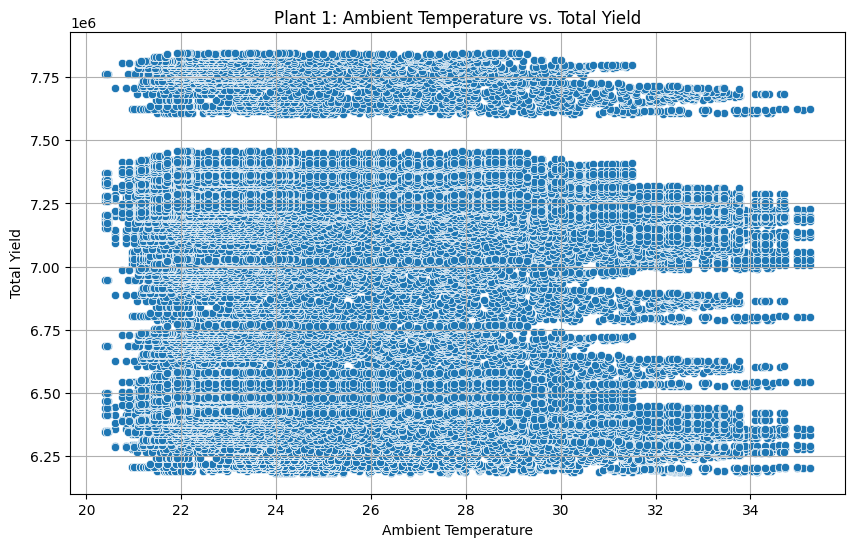


Plant 1 Merged DataFrame Head (Ambient/Module Temp/Irradiation vs Power Generation):


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,0.0,0.0,25.184316,22.857507,0.0
1,2020-05-15,4135001,0.0,0.0,25.184316,22.857507,0.0
2,2020-05-15,4135001,0.0,0.0,25.184316,22.857507,0.0
3,2020-05-15,4135001,0.0,0.0,25.184316,22.857507,0.0
4,2020-05-15,4135001,0.0,0.0,25.184316,22.857507,0.0


Correlation between Module Temperature and DC Power for Plant 1: 0.9513
Correlation between Module Temperature and AC Power for Plant 1: 0.9515


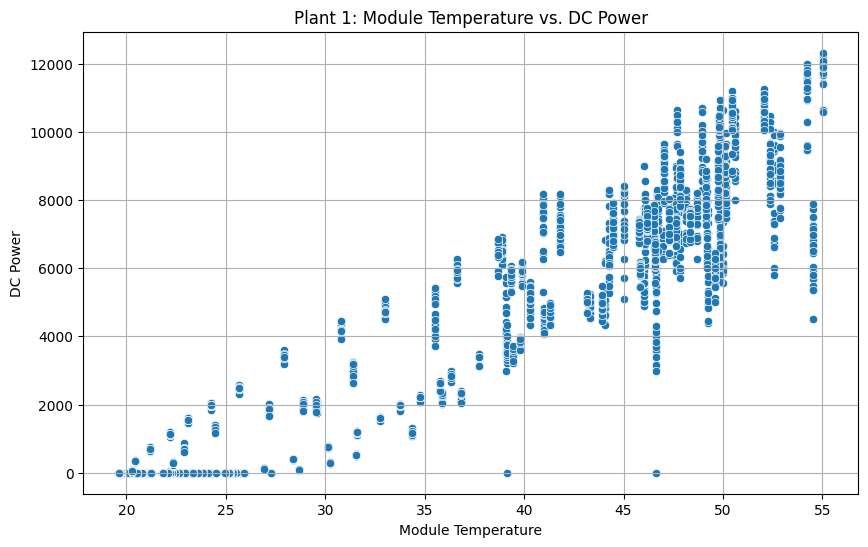

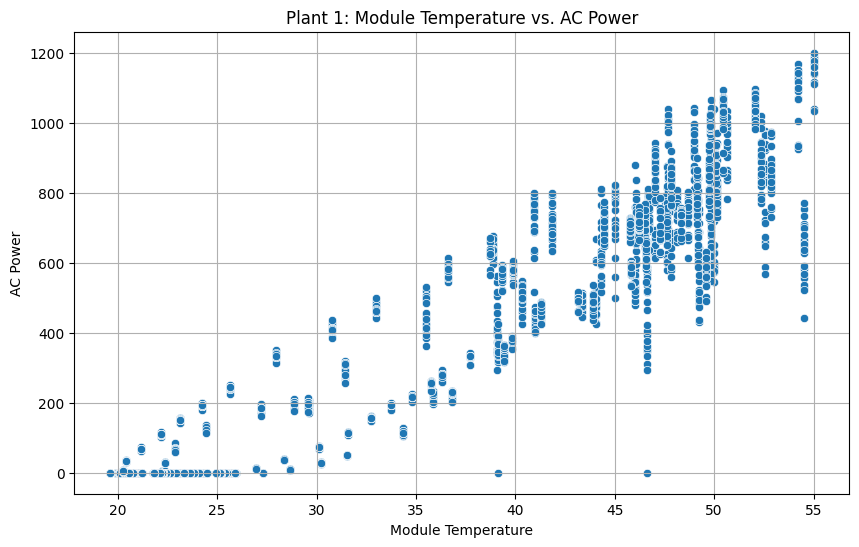

Correlation between Irradiation and DC Power for Plant 1: 0.9917
Correlation between Irradiation and AC Power for Plant 1: 0.9917


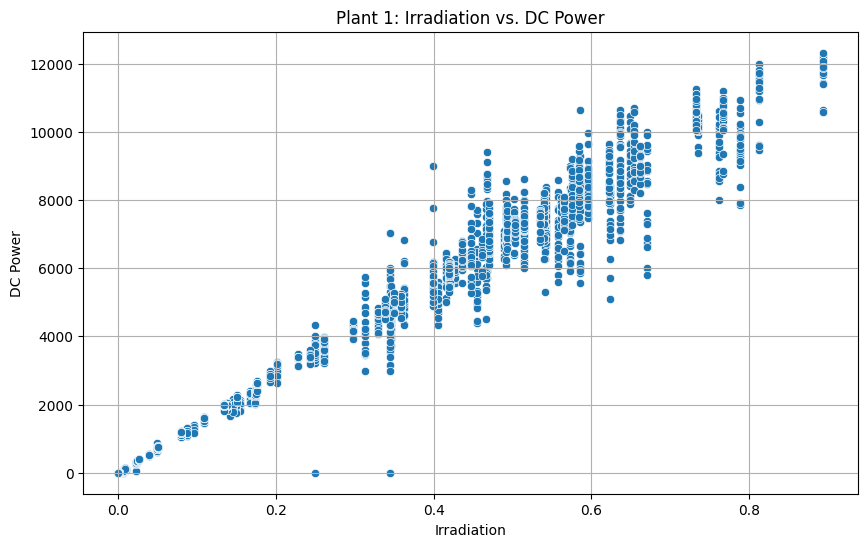

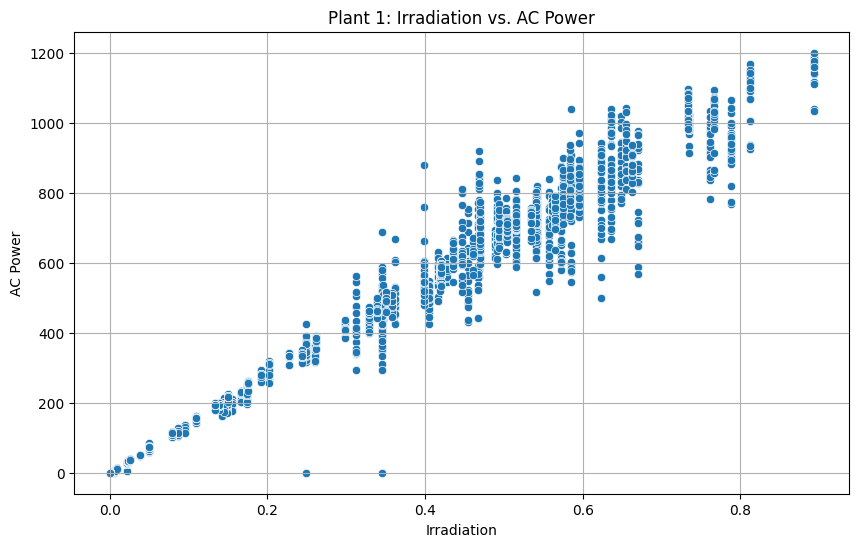

Correlation between Ambient Temperature and DC Power for Plant 1: 0.6623
Correlation between Ambient Temperature and AC Power for Plant 1: 0.6625


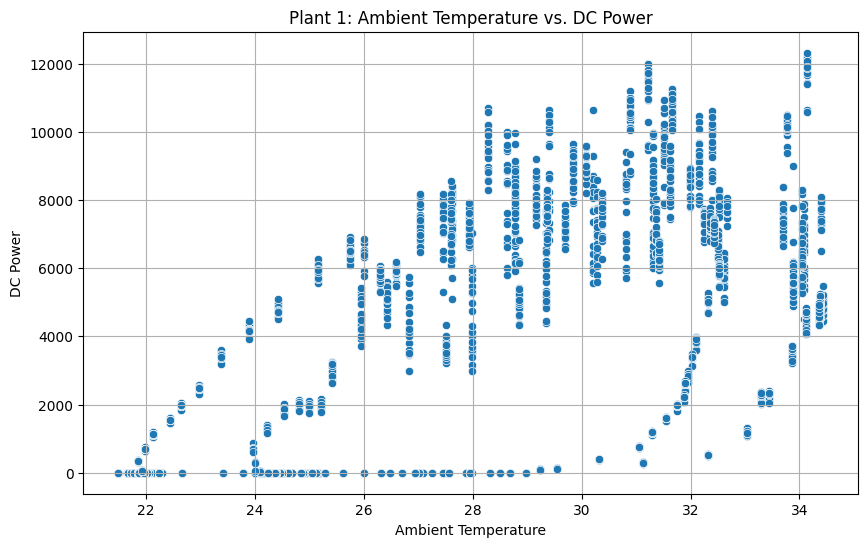

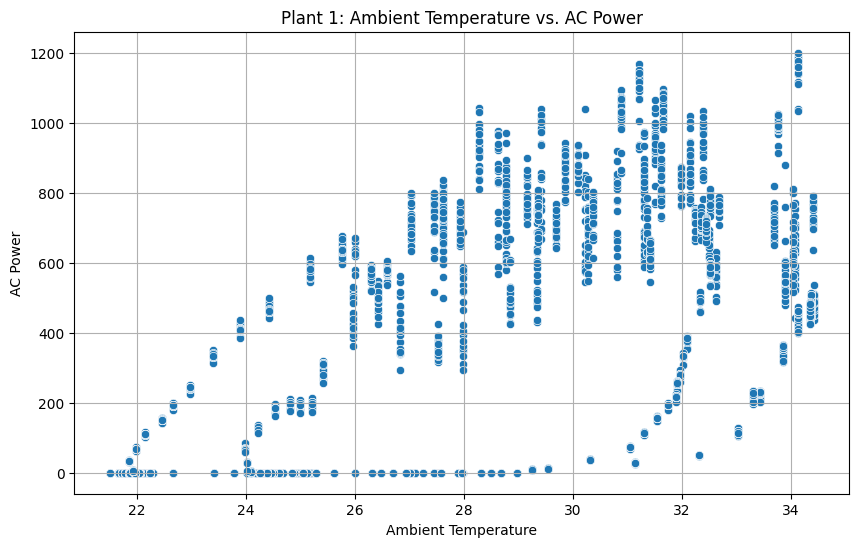


--- Processing Plant 2 ---
Plant 2 Merged DataFrame Head (Ambient Temp vs Total Yield):


,DATE_TIME,PLANT_ID,TOTAL_YIELD,AMBIENT_TEMPERATURE
0,2020-05-15,4136001,2.429011e+06,27.004764
1,2020-05-15,4136001,1.215279e+09,27.004764
2,2020-05-15,4136001,2.247720e+09,27.004764
3,2020-05-15,4136001,1.704250e+06,27.004764
4,2020-05-15,4136001,1.994153e+07,27.004764



Correlation between Ambient Temperature and Total Yield for Plant 2: 0.0028


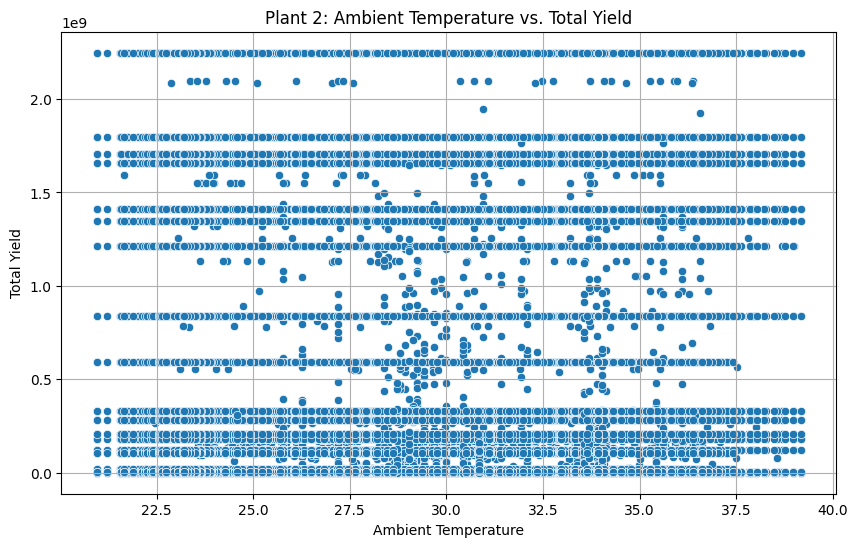


Plant 2 Merged DataFrame Head (Ambient/Module Temp/Irradiation vs Power Generation):


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4136001,0.0,0.0,27.004764,25.060789,0.0
1,2020-05-15,4136001,0.0,0.0,27.004764,25.060789,0.0
2,2020-05-15,4136001,0.0,0.0,27.004764,25.060789,0.0
3,2020-05-15,4136001,0.0,0.0,27.004764,25.060789,0.0
4,2020-05-15,4136001,0.0,0.0,27.004764,25.060789,0.0


Correlation between Module Temperature and DC Power for Plant 2: 0.7737
Correlation between Module Temperature and AC Power for Plant 2: 0.7737


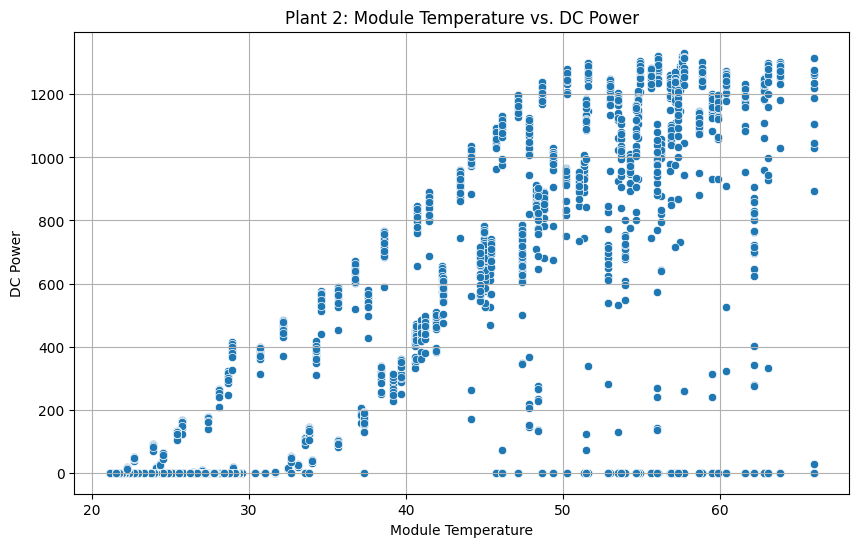

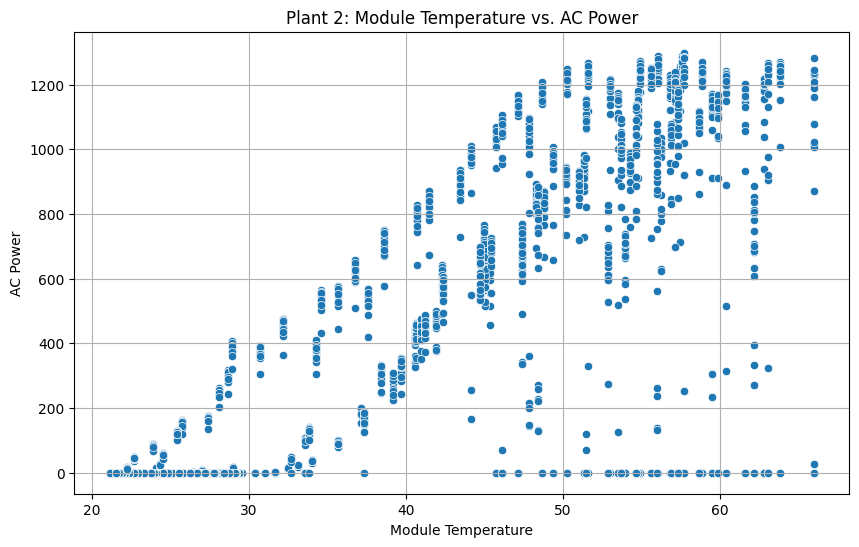

Correlation between Irradiation and DC Power for Plant 2: 0.8136
Correlation between Irradiation and AC Power for Plant 2: 0.8135


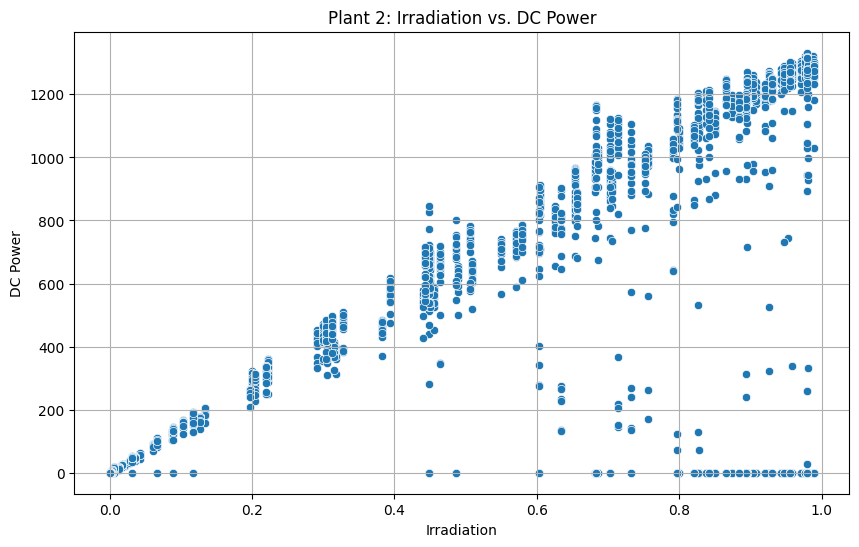

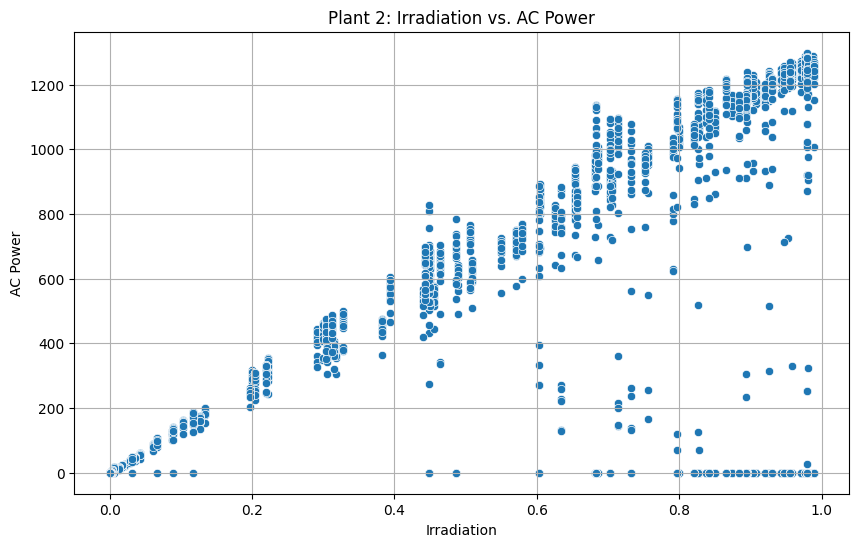

Correlation between Ambient Temperature and DC Power for Plant 2: 0.5859
Correlation between Ambient Temperature and AC Power for Plant 2: 0.5860


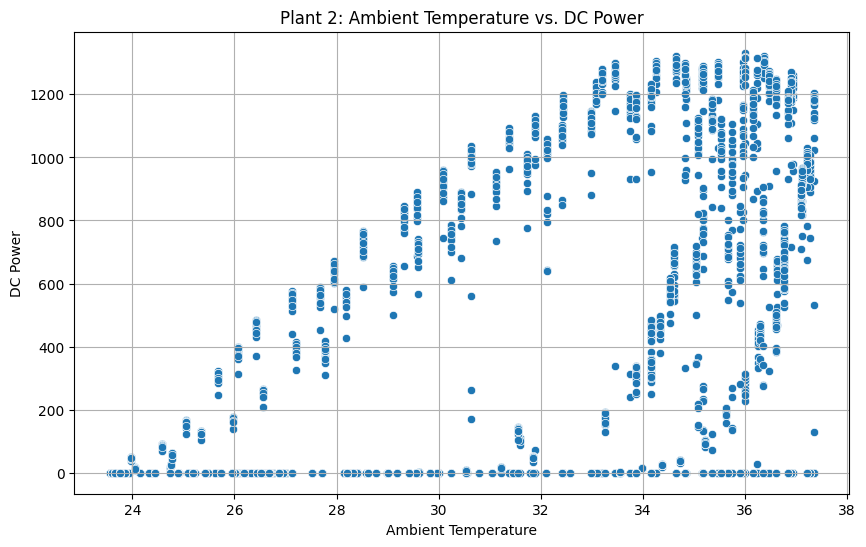

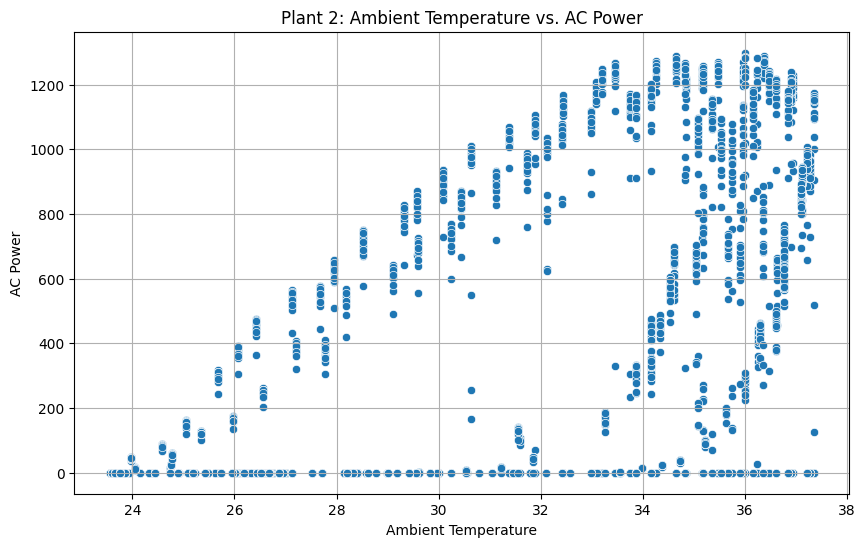

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define file paths
plant1_generation_path = '/content/Plant_1_Generation_Data.csv'
plant2_generation_path = '/content/Plant_2_Generation_Data.csv'
plant1_weather_path = '/content/Plant_1_Weather_Sensor_Data.csv'
plant2_weather_path = '/content/Plant_2_Weather_Sensor_Data.csv'

# Define a reduced time window for plotting
end_date_for_plot = pd.to_datetime('2020-05-16 23:45:00')

# --- Process Plant 1 Data ---
print("\n--- Processing Plant 1 ---")
try:
    df_gen1 = pd.read_csv(plant1_generation_path)
    df_weather1 = pd.read_csv(plant1_weather_path)
except FileNotFoundError as e:
    print(f"Error loading Plant 1 data: {e}")
    df_gen1 = pd.DataFrame()
    df_weather1 = pd.DataFrame()

if not df_gen1.empty and not df_weather1.empty:
    # Convert DATE_TIME to datetime objects
    df_gen1['DATE_TIME'] = pd.to_datetime(df_gen1['DATE_TIME'], errors='coerce', dayfirst=True)
    df_weather1['DATE_TIME'] = pd.to_datetime(df_weather1['DATE_TIME'], errors='coerce')

    # Drop rows where DATE_TIME conversion failed
    df_gen1.dropna(subset=['DATE_TIME'], inplace=True)
    df_weather1.dropna(subset=['DATE_TIME'], inplace=True)

    # Merge Plant 1 data for Ambient Temp vs Total Yield
    merged_df_plant1 = pd.merge(
        df_gen1[['DATE_TIME', 'PLANT_ID', 'TOTAL_YIELD']],
        df_weather1[['DATE_TIME', 'PLANT_ID', 'AMBIENT_TEMPERATURE']],
        on=['DATE_TIME', 'PLANT_ID'],
        how='inner'
    )

    print("Plant 1 Merged DataFrame Head (Ambient Temp vs Total Yield):")
    display(merged_df_plant1.head())

    # Calculate correlation for Plant 1 (Ambient Temp vs Total Yield)
    if not merged_df_plant1.empty:
        corr_plant1_ambient_total = merged_df_plant1['AMBIENT_TEMPERATURE'].corr(merged_df_plant1['TOTAL_YIELD'])
        print(f"\nCorrelation between Ambient Temperature and Total Yield for Plant 1: {corr_plant1_ambient_total:.4f}")

        # Plot scatter chart for Plant 1 (Ambient Temp vs Total Yield)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='AMBIENT_TEMPERATURE', y='TOTAL_YIELD', data=merged_df_plant1)
        plt.title('Plant 1: Ambient Temperature vs. Total Yield')
        plt.xlabel('Ambient Temperature')
        plt.ylabel('Total Yield')
        plt.grid(True)
        plt.show()
    else:
        print("Plant 1 merged DataFrame (Ambient Temp vs Total Yield) is empty, cannot calculate correlation or plot.")

    # Merge Plant 1 data for Ambient Temp, Module Temp and Irradiation vs Power Generation
    merged_power_weather_plant1 = pd.merge(
        df_gen1[['DATE_TIME', 'PLANT_ID', 'DC_POWER', 'AC_POWER']],
        df_weather1[['DATE_TIME', 'PLANT_ID', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']],
        on=['DATE_TIME', 'PLANT_ID'],
        how='inner'
    )

    # Filter data for a smaller time window for plotting
    merged_power_weather_plant1 = merged_power_weather_plant1[merged_power_weather_plant1['DATE_TIME'] <= end_date_for_plot]

    print("\nPlant 1 Merged DataFrame Head (Ambient/Module Temp/Irradiation vs Power Generation):")
    display(merged_power_weather_plant1.head())

    # Calculate correlations for Plant 1 (Module Temp vs Power Generation)
    if not merged_power_weather_plant1.empty:
        corr_plant1_module_dc = merged_power_weather_plant1['MODULE_TEMPERATURE'].corr(merged_power_weather_plant1['DC_POWER'])
        corr_plant1_module_ac = merged_power_weather_plant1['MODULE_TEMPERATURE'].corr(merged_power_weather_plant1['AC_POWER'])
        print(f"Correlation between Module Temperature and DC Power for Plant 1: {corr_plant1_module_dc:.4f}")
        print(f"Correlation between Module Temperature and AC Power for Plant 1: {corr_plant1_module_ac:.4f}")

        # Plot scatter chart for Plant 1 (Module Temp vs DC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='MODULE_TEMPERATURE', y='DC_POWER', data=merged_power_weather_plant1)
        plt.title('Plant 1: Module Temperature vs. DC Power')
        plt.xlabel('Module Temperature')
        plt.ylabel('DC Power')
        plt.grid(True)
        plt.show()

        # Plot scatter chart for Plant 1 (Module Temp vs AC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='MODULE_TEMPERATURE', y='AC_POWER', data=merged_power_weather_plant1)
        plt.title('Plant 1: Module Temperature vs. AC Power')
        plt.xlabel('Module Temperature')
        plt.ylabel('AC Power')
        plt.grid(True)
        plt.show()

        # Calculate correlations for Plant 1 (Irradiation vs Power Generation)
        corr_plant1_irradiation_dc = merged_power_weather_plant1['IRRADIATION'].corr(merged_power_weather_plant1['DC_POWER'])
        corr_plant1_irradiation_ac = merged_power_weather_plant1['IRRADIATION'].corr(merged_power_weather_plant1['AC_POWER'])
        print(f"Correlation between Irradiation and DC Power for Plant 1: {corr_plant1_irradiation_dc:.4f}")
        print(f"Correlation between Irradiation and AC Power for Plant 1: {corr_plant1_irradiation_ac:.4f}")

        # Plot scatter chart for Plant 1 (Irradiation vs DC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='IRRADIATION', y='DC_POWER', data=merged_power_weather_plant1)
        plt.title('Plant 1: Irradiation vs. DC Power')
        plt.xlabel('Irradiation')
        plt.ylabel('DC Power')
        plt.grid(True)
        plt.show()

        # Plot scatter chart for Plant 1 (Irradiation vs AC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='IRRADIATION', y='AC_POWER', data=merged_power_weather_plant1)
        plt.title('Plant 1: Irradiation vs. AC Power')
        plt.xlabel('Irradiation')
        plt.ylabel('AC Power')
        plt.grid(True)
        plt.show()

        # Calculate correlations for Plant 1 (Ambient Temp vs Power Generation)
        corr_plant1_ambient_dc = merged_power_weather_plant1['AMBIENT_TEMPERATURE'].corr(merged_power_weather_plant1['DC_POWER'])
        corr_plant1_ambient_ac = merged_power_weather_plant1['AMBIENT_TEMPERATURE'].corr(merged_power_weather_plant1['AC_POWER'])
        print(f"Correlation between Ambient Temperature and DC Power for Plant 1: {corr_plant1_ambient_dc:.4f}")
        print(f"Correlation between Ambient Temperature and AC Power for Plant 1: {corr_plant1_ambient_ac:.4f}")

        # Plot scatter chart for Plant 1 (Ambient Temp vs DC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='AMBIENT_TEMPERATURE', y='DC_POWER', data=merged_power_weather_plant1)
        plt.title('Plant 1: Ambient Temperature vs. DC Power')
        plt.xlabel('Ambient Temperature')
        plt.ylabel('DC Power')
        plt.grid(True)
        plt.show()

        # Plot scatter chart for Plant 1 (Ambient Temp vs AC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='AMBIENT_TEMPERATURE', y='AC_POWER', data=merged_power_weather_plant1)
        plt.title('Plant 1: Ambient Temperature vs. AC Power')
        plt.xlabel('Ambient Temperature')
        plt.ylabel('AC Power')
        plt.grid(True)
        plt.show()
    else:
        print("Plant 1 merged DataFrame (Ambient/Module Temp/Irradiation vs Power Generation) is empty, cannot calculate correlation.")

else:
    print("Could not load or process Plant 1 data.")


# --- Process Plant 2 Data ---
print("\n--- Processing Plant 2 ---")
try:
    df_gen2 = pd.read_csv(plant2_generation_path)
    df_weather2 = pd.read_csv(plant2_weather_path)
except FileNotFoundError as e:
    print(f"Error loading Plant 2 data: {e}")
    df_gen2 = pd.DataFrame()
    df_weather2 = pd.DataFrame()

if not df_gen2.empty and not df_weather2.empty:
    # Convert DATE_TIME to datetime objects
    df_gen2['DATE_TIME'] = pd.to_datetime(df_gen2['DATE_TIME'], errors='coerce')
    df_weather2['DATE_TIME'] = pd.to_datetime(df_weather2['DATE_TIME'], errors='coerce')

    # Drop rows where DATE_TIME conversion failed
    df_gen2.dropna(subset=['DATE_TIME'], inplace=True)
    df_weather2.dropna(subset=['DATE_TIME'], inplace=True)

    # Merge Plant 2 data for Ambient Temp vs Total Yield
    merged_df_plant2 = pd.merge(
        df_gen2[['DATE_TIME', 'PLANT_ID', 'TOTAL_YIELD']],
        df_weather2[['DATE_TIME', 'PLANT_ID', 'AMBIENT_TEMPERATURE']],
        on=['DATE_TIME', 'PLANT_ID'],
        how='inner'
    )

    print("Plant 2 Merged DataFrame Head (Ambient Temp vs Total Yield):")
    display(merged_df_plant2.head())

    # Calculate correlation for Plant 2 (Ambient Temp vs Total Yield)
    if not merged_df_plant2.empty:
        corr_plant2_ambient_total = merged_df_plant2['AMBIENT_TEMPERATURE'].corr(merged_df_plant2['TOTAL_YIELD'])
        print(f"\nCorrelation between Ambient Temperature and Total Yield for Plant 2: {corr_plant2_ambient_total:.4f}")

        # Plot scatter chart for Plant 2 (Ambient Temp vs Total Yield)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='AMBIENT_TEMPERATURE', y='TOTAL_YIELD', data=merged_df_plant2)
        plt.title('Plant 2: Ambient Temperature vs. Total Yield')
        plt.xlabel('Ambient Temperature')
        plt.ylabel('Total Yield')
        plt.grid(True)
        plt.show()
    else:
        print("Plant 2 merged DataFrame (Ambient Temp vs Total Yield) is empty, cannot calculate correlation or plot.")

    # Merge Plant 2 data for Ambient Temp, Module Temp and Irradiation vs Power Generation
    merged_power_weather_plant2 = pd.merge(
        df_gen2[['DATE_TIME', 'PLANT_ID', 'DC_POWER', 'AC_POWER']],
        df_weather2[['DATE_TIME', 'PLANT_ID', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']],
        on=['DATE_TIME', 'PLANT_ID'],
        how='inner'
    )

    # Filter data for a smaller time window for plotting
    merged_power_weather_plant2 = merged_power_weather_plant2[merged_power_weather_plant2['DATE_TIME'] <= end_date_for_plot]

    print("\nPlant 2 Merged DataFrame Head (Ambient/Module Temp/Irradiation vs Power Generation):")
    display(merged_power_weather_plant2.head())

    # Calculate correlations for Plant 2 (Module Temp vs Power Generation)
    if not merged_power_weather_plant2.empty:
        corr_plant2_module_dc = merged_power_weather_plant2['MODULE_TEMPERATURE'].corr(merged_power_weather_plant2['DC_POWER'])
        corr_plant2_module_ac = merged_power_weather_plant2['MODULE_TEMPERATURE'].corr(merged_power_weather_plant2['AC_POWER'])
        print(f"Correlation between Module Temperature and DC Power for Plant 2: {corr_plant2_module_dc:.4f}")
        print(f"Correlation between Module Temperature and AC Power for Plant 2: {corr_plant2_module_ac:.4f}")

        # Plot scatter chart for Plant 2 (Module Temp vs DC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='MODULE_TEMPERATURE', y='DC_POWER', data=merged_power_weather_plant2)
        plt.title('Plant 2: Module Temperature vs. DC Power')
        plt.xlabel('Module Temperature')
        plt.ylabel('DC Power')
        plt.grid(True)
        plt.show()

        # Plot scatter chart for Plant 2 (Module Temp vs AC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='MODULE_TEMPERATURE', y='AC_POWER', data=merged_power_weather_plant2)
        plt.title('Plant 2: Module Temperature vs. AC Power')
        plt.xlabel('Module Temperature')
        plt.ylabel('AC Power')
        plt.grid(True)
        plt.show()

        # Calculate correlations for Plant 2 (Irradiation vs Power Generation)
        corr_plant2_irradiation_dc = merged_power_weather_plant2['IRRADIATION'].corr(merged_power_weather_plant2['DC_POWER'])
        corr_plant2_irradiation_ac = merged_power_weather_plant2['IRRADIATION'].corr(merged_power_weather_plant2['AC_POWER'])
        print(f"Correlation between Irradiation and DC Power for Plant 2: {corr_plant2_irradiation_dc:.4f}")
        print(f"Correlation between Irradiation and AC Power for Plant 2: {corr_plant2_irradiation_ac:.4f}")

        # Plot scatter chart for Plant 2 (Irradiation vs DC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='IRRADIATION', y='DC_POWER', data=merged_power_weather_plant2)
        plt.title('Plant 2: Irradiation vs. DC Power')
        plt.xlabel('Irradiation')
        plt.ylabel('DC Power')
        plt.grid(True)
        plt.show()

        # Plot scatter chart for Plant 2 (Irradiation vs AC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='IRRADIATION', y='AC_POWER', data=merged_power_weather_plant2)
        plt.title('Plant 2: Irradiation vs. AC Power')
        plt.xlabel('Irradiation')
        plt.ylabel('AC Power')
        plt.grid(True)
        plt.show()

        # Calculate correlations for Plant 2 (Ambient Temp vs Power Generation)
        corr_plant2_ambient_dc = merged_power_weather_plant2['AMBIENT_TEMPERATURE'].corr(merged_power_weather_plant2['DC_POWER'])
        corr_plant2_ambient_ac = merged_power_weather_plant2['AMBIENT_TEMPERATURE'].corr(merged_power_weather_plant2['AC_POWER'])
        print(f"Correlation between Ambient Temperature and DC Power for Plant 2: {corr_plant2_ambient_dc:.4f}")
        print(f"Correlation between Ambient Temperature and AC Power for Plant 2: {corr_plant2_ambient_ac:.4f}")

        # Plot scatter chart for Plant 2 (Ambient Temp vs DC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='AMBIENT_TEMPERATURE', y='DC_POWER', data=merged_power_weather_plant2)
        plt.title('Plant 2: Ambient Temperature vs. DC Power')
        plt.xlabel('Ambient Temperature')
        plt.ylabel('DC Power')
        plt.grid(True)
        plt.show()

        # Plot scatter chart for Plant 2 (Ambient Temp vs AC Power)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='AMBIENT_TEMPERATURE', y='AC_POWER', data=merged_power_weather_plant2)
        plt.title('Plant 2: Ambient Temperature vs. AC Power')
        plt.xlabel('Ambient Temperature')
        plt.ylabel('AC Power')
        plt.grid(True)
        plt.show()
    else:
        print("Plant 2 merged DataFrame (Ambient/Module Temp/Irradiation vs Power Generation) is empty, cannot calculate correlation.")
else:
    print("Could not load or process Plant 2 data.")

### Data Cleaning: Handling Missing Sensor Data

Sensor data can often have missing values due to various reasons (e.g., sensor malfunctions, transmission errors). To ensure the quality of our analysis, we will implement a cleaning strategy:

1.  **Linear Interpolation**: For numerical columns (like power, temperature, irradiation, and yield), we will use linear interpolation to fill in missing values. This method estimates missing data points based on the values of adjacent data points, which is suitable for time-series data.
2.  **Forward Fill (ffill) and Backward Fill (bfill)**: After interpolation, any remaining `NaN` values (which might occur at the very beginning or end of the time series if the first or last values are missing) will be filled using forward-fill and then backward-fill. This ensures no `NaN` values remain in the numerical columns.
3.  **Saving Cleaned Data**: The cleaned DataFrames will be saved to new CSV files with a `_cleaned` suffix for easy identification.

In [ ]:
import pandas as pd
import numpy as np

# Define file paths (copied from 19ff2e2b to ensure availability in this cell)
plant1_generation_path = '/content/Plant_1_Generation_Data.csv'
plant2_generation_path = '/content/Plant_2_Generation_Data.csv'
plant1_weather_path = '/content/Plant_1_Weather_Sensor_Data.csv'
plant2_weather_path = '/content/Plant_2_Weather_Sensor_Data.csv'

# Load and pre-process dataframes for robustness
# This ensures df_gen1, df_weather1, df_gen2, df_weather2 are defined and basic DATE_TIME processing is done.
# This prevents NameError if the previous loading cell was not run or kernel state was lost.
print("Loading dataframes for cleaning...")

try:
    df_gen1 = pd.read_csv(plant1_generation_path)
    df_gen1['DATE_TIME'] = pd.to_datetime(df_gen1['DATE_TIME'], errors='coerce', dayfirst=True)
    df_gen1.dropna(subset=['DATE_TIME'], inplace=True)
    print(f"Loaded {plant1_generation_path} with {len(df_gen1)} rows.")
except FileNotFoundError as e:
    print(f"Error loading Plant 1 Generation data: {e}. Initializing as empty DataFrame.")
    df_gen1 = pd.DataFrame()

try:
    df_weather1 = pd.read_csv(plant1_weather_path)
    df_weather1['DATE_TIME'] = pd.to_datetime(df_weather1['DATE_TIME'], errors='coerce')
    df_weather1.dropna(subset=['DATE_TIME'], inplace=True)
    print(f"Loaded {plant1_weather_path} with {len(df_weather1)} rows.")
except FileNotFoundError as e:
    print(f"Error loading Plant 1 Weather data: {e}. Initializing as empty DataFrame.")
    df_weather1 = pd.DataFrame()

try:
    df_gen2 = pd.read_csv(plant2_generation_path)
    df_gen2['DATE_TIME'] = pd.to_datetime(df_gen2['DATE_TIME'], errors='coerce')
    df_gen2.dropna(subset=['DATE_TIME'], inplace=True)
    print(f"Loaded {plant2_generation_path} with {len(df_gen2)} rows.")
except FileNotFoundError as e:
    print(f"Error loading Plant 2 Generation data: {e}. Initializing as empty DataFrame.")
    df_gen2 = pd.DataFrame()

try:
    df_weather2 = pd.read_csv(plant2_weather_path)
    df_weather2['DATE_TIME'] = pd.to_datetime(df_weather2['DATE_TIME'], errors='coerce')
    df_weather2.dropna(subset=['DATE_TIME'], inplace=True)
    print(f"Loaded {plant2_weather_path} with {len(df_weather2)} rows.")
except FileNotFoundError as e:
    print(f"Error loading Plant 2 Weather data: {e}. Initializing as empty DataFrame.")
    df_weather2 = pd.DataFrame()

print("Dataframe loading complete.")

def clean_dataframe(df, file_name):
    """
    Cleans a DataFrame by handling missing numerical values using interpolation and
    forward/backward fill, and saves the cleaned DataFrame to a new CSV file.
    Assumes DATE_TIME conversion and NaT dropping have already been handled outside this function.

    Args:
        df (pd.DataFrame): The input DataFrame to clean.
        file_name (str): The original file name (e.g., 'Plant_1_Generation_Data.csv').

    Returns:
        pd.DataFrame: The cleaned DataFrame.
    """
    print(f"\n--- Cleaning DataFrame: {file_name} ---")
    initial_nulls = df.isnull().sum()
    print("Initial missing values per column:\n", initial_nulls[initial_nulls > 0])

    # Identify numerical columns for interpolation
    numeric_cols = df.select_dtypes(include=np.number).columns

    if not numeric_cols.empty:
        # Apply linear interpolation for numerical columns
        df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit_direction='both')
        # Fill any remaining NaNs (e.g., at ends if entire column was NaN) with ffill then bfill
        df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')

    final_nulls = df.isnull().sum()
    print("Final missing values per column after cleaning:\n", final_nulls[final_nulls > 0])
    if final_nulls.sum() == 0:
        print("All numerical missing values handled.")
    else:
        print("Some non-numerical missing values might remain or could not be filled.")

    return df

# Apply cleaning to each DataFrame and save them

# Plant 1 Generation Data
if not df_gen1.empty:
    df_gen1_cleaned = clean_dataframe(df_gen1.copy(), 'Plant_1_Generation_Data.csv')
    cleaned_gen1_path = '/content/Plant_1_Generation_Data_cleaned.csv'
    df_gen1_cleaned.to_csv(cleaned_gen1_path, index=False)
    print(f"Cleaned Plant 1 Generation data saved to: {cleaned_gen1_path}")
    # Update the original df_gen1 to the cleaned version for subsequent cells
    df_gen1 = df_gen1_cleaned

# Plant 1 Weather Data
if not df_weather1.empty:
    df_weather1_cleaned = clean_dataframe(df_weather1.copy(), 'Plant_1_Weather_Sensor_Data.csv')
    cleaned_weather1_path = '/content/Plant_1_Weather_Sensor_Data_cleaned.csv'
    df_weather1_cleaned.to_csv(cleaned_weather1_path, index=False)
    print(f"Cleaned Plant 1 Weather data saved to: {cleaned_weather1_path}")
    # Update the original df_weather1 to the cleaned version for subsequent cells
    df_weather1 = df_weather1_cleaned

# Plant 2 Generation Data
if not df_gen2.empty:
    df_gen2_cleaned = clean_dataframe(df_gen2.copy(), 'Plant_2_Generation_Data.csv')
    cleaned_gen2_path = '/content/Plant_2_Generation_Data_cleaned.csv'
    df_gen2_cleaned.to_csv(cleaned_gen2_path, index=False)
    print(f"Cleaned Plant 2 Generation data saved to: {cleaned_gen2_path}")
    # Update the original df_gen2 to the cleaned version for subsequent cells
    df_gen2 = df_gen2_cleaned

# Plant 2 Weather Data
if not df_weather2.empty:
    df_weather2_cleaned = clean_dataframe(df_weather2.copy(), 'Plant_2_Weather_Sensor_Data.csv')
    cleaned_weather2_path = '/content/Plant_2_Weather_Sensor_Data_cleaned.csv'
    df_weather2_cleaned.to_csv(cleaned_weather2_path, index=False)
    print(f"Cleaned Plant 2 Weather data saved to: {cleaned_weather2_path}")
    # Update the original df_weather2 to the cleaned version for subsequent cells
    df_weather2 = df_weather2_cleaned

print("\nData cleaning and saving complete. The original dataframes in this notebook have been updated with the cleaned versions.")

Loading dataframes for cleaning...
Loaded /content/Plant_1_Generation_Data.csv with 68778 rows.
Loaded /content/Plant_1_Weather_Sensor_Data.csv with 3182 rows.
Loaded /content/Plant_2_Generation_Data.csv with 67698 rows.
Loaded /content/Plant_2_Weather_Sensor_Data.csv with 3259 rows.
Dataframe loading complete.

--- Cleaning DataFrame: Plant_1_Generation_Data.csv ---
Initial missing values per column:
 Series([], dtype: int64)
Final missing values per column after cleaning:
 Series([], dtype: int64)
All numerical missing values handled.


/tmp/ipykernel_2833/1244942400.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')


Cleaned Plant 1 Generation data saved to: /content/Plant_1_Generation_Data_cleaned.csv

--- Cleaning DataFrame: Plant_1_Weather_Sensor_Data.csv ---
Initial missing values per column:
 Series([], dtype: int64)
Final missing values per column after cleaning:
 Series([], dtype: int64)
All numerical missing values handled.
Cleaned Plant 1 Weather data saved to: /content/Plant_1_Weather_Sensor_Data_cleaned.csv

--- Cleaning DataFrame: Plant_2_Generation_Data.csv ---
Initial missing values per column:
 Series([], dtype: int64)
Final missing values per column after cleaning:
 Series([], dtype: int64)
All numerical missing values handled.


/tmp/ipykernel_2833/1244942400.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_2833/1244942400.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')


Cleaned Plant 2 Generation data saved to: /content/Plant_2_Generation_Data_cleaned.csv

--- Cleaning DataFrame: Plant_2_Weather_Sensor_Data.csv ---
Initial missing values per column:
 Series([], dtype: int64)
Final missing values per column after cleaning:
 Series([], dtype: int64)
All numerical missing values handled.
Cleaned Plant 2 Weather data saved to: /content/Plant_2_Weather_Sensor_Data_cleaned.csv

Data cleaning and saving complete. The original dataframes in this notebook have been updated with the cleaned versions.


/tmp/ipykernel_2833/1244942400.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')


### Calculate and Analyze Efficiency Metrics

To understand the performance of each solar plant, we will calculate efficiency metrics. A key metric is the **Inverter Efficiency**, which represents how effectively the DC power produced by the solar panels is converted into usable AC power by the inverters.

**Inverter Efficiency = AC_POWER / DC_POWER**

We will also consider the impact of environmental factors like `IRRADIATION` and `MODULE_TEMPERATURE` on power generation.

**Note**: When `DC_POWER` is zero, the inverter efficiency is undefined or effectively zero. We will handle these cases by either filtering them out for efficiency calculations or assigning an efficiency of 0.

In [ ]:
# Merge cleaned generation and weather data for Plant 1
# Use the _cleaned dataframes which are updated in the previous cell
merged_plant1_data = pd.merge(
    df_gen1[['DATE_TIME', 'PLANT_ID', 'DC_POWER', 'AC_POWER', 'TOTAL_YIELD']],
    df_weather1[['DATE_TIME', 'PLANT_ID', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']],
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)

# Calculate Inverter Efficiency for Plant 1
# Avoid division by zero: only calculate when DC_POWER > 0
merged_plant1_data['INVERTER_EFFICIENCY'] = np.where(
    merged_plant1_data['DC_POWER'] > 0,
    merged_plant1_data['AC_POWER'] / merged_plant1_data['DC_POWER'],
    0 # Assign 0 efficiency when DC_POWER is 0
)

# Ensure efficiency doesn't exceed 1 (100%) due to potential sensor inaccuracies or edge cases
merged_plant1_data['INVERTER_EFFICIENCY'] = merged_plant1_data['INVERTER_EFFICIENCY'].clip(upper=1.0)

print("\n--- Plant 1 Efficiency Metrics ---")
display(merged_plant1_data[['DATE_TIME', 'DC_POWER', 'AC_POWER', 'INVERTER_EFFICIENCY']].head())
print("Summary Statistics for Plant 1 Inverter Efficiency (where DC_POWER > 0):")
display(merged_plant1_data[merged_plant1_data['DC_POWER'] > 0]['INVERTER_EFFICIENCY'].describe())

# Merge cleaned generation and weather data for Plant 2
merged_plant2_data = pd.merge(
    df_gen2[['DATE_TIME', 'PLANT_ID', 'DC_POWER', 'AC_POWER', 'TOTAL_YIELD']],
    df_weather2[['DATE_TIME', 'PLANT_ID', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']],
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)

# Calculate Inverter Efficiency for Plant 2
merged_plant2_data['INVERTER_EFFICIENCY'] = np.where(
    merged_plant2_data['DC_POWER'] > 0,
    merged_plant2_data['AC_POWER'] / merged_plant2_data['DC_POWER'],
    0
)
merged_plant2_data['INVERTER_EFFICIENCY'] = merged_plant2_data['INVERTER_EFFICIENCY'].clip(upper=1.0)

print("\n--- Plant 2 Efficiency Metrics ---")
display(merged_plant2_data[['DATE_TIME', 'DC_POWER', 'AC_POWER', 'INVERTER_EFFICIENCY']].head())
print("Summary Statistics for Plant 2 Inverter Efficiency (where DC_POWER > 0):")
display(merged_plant2_data[merged_plant2_data['DC_POWER'] > 0]['INVERTER_EFFICIENCY'].describe())


--- Plant 1 Efficiency Metrics ---


,DATE_TIME,DC_POWER,AC_POWER,INVERTER_EFFICIENCY
0,2020-05-15,0.0,0.0,0.0
1,2020-05-15,0.0,0.0,0.0
2,2020-05-15,0.0,0.0,0.0
3,2020-05-15,0.0,0.0,0.0
4,2020-05-15,0.0,0.0,0.0


Summary Statistics for Plant 1 Inverter Efficiency (where DC_POWER > 0):


,INVERTER_EFFICIENCY
count,36823.000000
mean,0.097719
std,0.000458
min,0.095552
25%,0.097579
50%,0.097845
75%,0.098014
max,0.106592



--- Plant 2 Efficiency Metrics ---


,DATE_TIME,DC_POWER,AC_POWER,INVERTER_EFFICIENCY
0,2020-05-15,0.0,0.0,0.0
1,2020-05-15,0.0,0.0,0.0
2,2020-05-15,0.0,0.0,0.0
3,2020-05-15,0.0,0.0,0.0
4,2020-05-15,0.0,0.0,0.0


Summary Statistics for Plant 2 Inverter Efficiency (where DC_POWER > 0):


,INVERTER_EFFICIENCY
count,32036.000000
mean,0.976804
std,0.005005
min,0.912790
25%,0.975014
50%,0.978432
75%,0.980247
max,1.000000


### Compute Ideal DC Power Output Based on Solar Irradiance

To estimate the *ideal* DC power output, we will use a simplified approach based on the observed data. We will find the maximum `DC_POWER` generated per unit of `IRRADIATION` when both are non-zero. This maximum ratio will serve as an 'ideal conversion efficiency' from irradiation to DC power for the given plant and its specific solar panel setup.

`IDEAL_DC_POWER = IRRADIATION × (Max DC_POWER / IRRADIATION Ratio)`

This metric will provide a benchmark to compare against the actual `DC_POWER` and `AC_POWER` outputs.

In [ ]:
print("\n--- Calculating Ideal DC Power for Plant 1 ---")
# Calculate DC_POWER per unit of IRRADIATION for Plant 1 when both are positive
plant1_power_per_irr = merged_plant1_data[
    (merged_plant1_data['IRRADIATION'] > 0) & (merged_plant1_data['DC_POWER'] > 0)
].copy()

if not plant1_power_per_irr.empty:
    plant1_power_per_irr['DC_POWER_PER_IRRADIATION'] = plant1_power_per_irr['DC_POWER'] / plant1_power_per_irr['IRRADIATION']
    max_dc_per_irr_plant1 = plant1_power_per_irr['DC_POWER_PER_IRRADIATION'].max()
    print(f"Plant 1: Maximum observed DC Power per Irradiation unit: {max_dc_per_irr_plant1:.4f}")

    # Calculate IDEAL_DC_POWER for Plant 1
    merged_plant1_data['IDEAL_DC_POWER'] = merged_plant1_data['IRRADIATION'] * max_dc_per_irr_plant1

    # Display comparison
    print("First 5 rows with Ideal DC Power for Plant 1:")
    display(merged_plant1_data[
        (merged_plant1_data['IRRADIATION'] > 0) # Show only periods with some irradiation
    ][['DATE_TIME', 'IRRADIATION', 'DC_POWER', 'IDEAL_DC_POWER', 'AC_POWER']].head())

    # Summary statistics for IDEAL_DC_POWER vs actual DC_POWER
    print("\nSummary Statistics for DC_POWER vs IDEAL_DC_POWER (Plant 1, where IRRADIATION > 0):")
    display(merged_plant1_data[
        merged_plant1_data['IRRADIATION'] > 0
    ][['DC_POWER', 'IDEAL_DC_POWER']].describe())
else:
    print("No data points with positive irradiation and DC power found for Plant 1 to calculate ideal power.")
    merged_plant1_data['IDEAL_DC_POWER'] = 0 # Assign 0 if no ideal can be calculated


print("\n--- Calculating Ideal DC Power for Plant 2 ---")
# Calculate DC_POWER per unit of IRRADIATION for Plant 2 when both are positive
plant2_power_per_irr = merged_plant2_data[
    (merged_plant2_data['IRRADIATION'] > 0) & (merged_plant2_data['DC_POWER'] > 0)
].copy()

if not plant2_power_per_irr.empty:
    plant2_power_per_irr['DC_POWER_PER_IRRADIATION'] = plant2_power_per_irr['DC_POWER'] / plant2_power_per_irr['IRRADIATION']
    max_dc_per_irr_plant2 = plant2_power_per_irr['DC_POWER_PER_IRRADIATION'].max()
    print(f"Plant 2: Maximum observed DC Power per Irradiation unit: {max_dc_per_irr_plant2:.4f}")

    # Calculate IDEAL_DC_POWER for Plant 2
    merged_plant2_data['IDEAL_DC_POWER'] = merged_plant2_data['IRRADIATION'] * max_dc_per_irr_plant2

    # Display comparison
    print("First 5 rows with Ideal DC Power for Plant 2:")
    display(merged_plant2_data[
        (merged_plant2_data['IRRADIATION'] > 0) # Show only periods with some irradiation
    ][['DATE_TIME', 'IRRADIATION', 'DC_POWER', 'IDEAL_DC_POWER', 'AC_POWER']].head())

    # Summary statistics for IDEAL_DC_POWER vs actual DC_POWER
    print("\nSummary Statistics for DC_POWER vs IDEAL_DC_POWER (Plant 2, where IRRADIATION > 0):")
    display(merged_plant2_data[
        merged_plant2_data['IRRADIATION'] > 0
    ][['DC_POWER', 'IDEAL_DC_POWER']].describe())
else:
    print("No data points with positive irradiation and DC power found for Plant 2 to calculate ideal power.")
    merged_plant2_data['IDEAL_DC_POWER'] = 0 # Assign 0 if no ideal can be calculated



--- Calculating Ideal DC Power for Plant 1 ---
Plant 1: Maximum observed DC Power per Irradiation unit: 28349.5050
First 5 rows with Ideal DC Power for Plant 1:


,DATE_TIME,IRRADIATION,DC_POWER,IDEAL_DC_POWER,AC_POWER
489,2020-05-15 05:45:00,0.000863,0.0,24.45772,0.0
490,2020-05-15 05:45:00,0.000863,0.0,24.45772,0.0
491,2020-05-15 05:45:00,0.000863,0.0,24.45772,0.0
492,2020-05-15 05:45:00,0.000863,0.0,24.45772,0.0
493,2020-05-15 05:45:00,0.000863,0.0,24.45772,0.0



Summary Statistics for DC_POWER vs IDEAL_DC_POWER (Plant 1, where IRRADIATION > 0):


,DC_POWER,IDEAL_DC_POWER
count,38376.000000,38376.000000
mean,5640.087085,11802.355220
std,3890.801823,8351.512162
min,0.000000,0.417782
25%,1972.214286,4032.624528
50%,5731.354166,11641.050060
75%,8738.031250,18154.134513
max,14471.125000,34633.225141



--- Calculating Ideal DC Power for Plant 2 ---
Plant 2: Maximum observed DC Power per Irradiation unit: 3674.7742
First 5 rows with Ideal DC Power for Plant 2:


,DATE_TIME,IRRADIATION,DC_POWER,IDEAL_DC_POWER,AC_POWER
506,2020-05-15 05:45:00,0.002838,0.0,10.42921,0.0
507,2020-05-15 05:45:00,0.002838,0.0,10.42921,0.0
508,2020-05-15 05:45:00,0.002838,0.0,10.42921,0.0
509,2020-05-15 05:45:00,0.002838,0.0,10.42921,0.0
510,2020-05-15 05:45:00,0.002838,0.0,10.42921,0.0



Summary Statistics for DC_POWER vs IDEAL_DC_POWER (Plant 2, where IRRADIATION > 0):


,DC_POWER,IDEAL_DC_POWER
count,38722.000000,38722.000000
mean,431.310678,1472.554436
std,400.571973,1153.874150
min,0.000000,0.004702
25%,45.232500,351.043767
50%,347.020000,1339.232907
75%,722.728810,2521.980124
max,1420.933333,4037.717160


### Detailed Performance Table: Plant 1 (DC Power > 0)

In [ ]:
print("Plant 1: Performance Summary (DC Power > 0)")
display(merged_plant1_data[
    merged_plant1_data['DC_POWER'] > 0
][['DATE_TIME', 'IRRADIATION', 'DC_POWER', 'IDEAL_DC_POWER', 'AC_POWER', 'INVERTER_EFFICIENCY']].head())

Plant 1: Performance Summary (DC Power > 0)


,DATE_TIME,IRRADIATION,DC_POWER,IDEAL_DC_POWER,AC_POWER,INVERTER_EFFICIENCY
510,2020-05-15 06:00:00,0.005887,37.142857,166.892322,3.585714,0.096538
511,2020-05-15 06:00:00,0.005887,53.500000,166.892322,5.162500,0.096495
512,2020-05-15 06:00:00,0.005887,58.000000,166.892322,5.585714,0.096305
513,2020-05-15 06:00:00,0.005887,58.428571,166.892322,5.628571,0.096333
514,2020-05-15 06:00:00,0.005887,54.375000,166.892322,5.250000,0.096552


### Detailed Performance Table: Plant 2 (DC Power > 0)

In [ ]:
print("Plant 2: Performance Summary (DC Power > 0)")
display(merged_plant2_data[
    merged_plant2_data['DC_POWER'] > 0
][['DATE_TIME', 'IRRADIATION', 'DC_POWER', 'IDEAL_DC_POWER', 'AC_POWER', 'INVERTER_EFFICIENCY']].head())

Plant 2: Performance Summary (DC Power > 0)


,DATE_TIME,IRRADIATION,DC_POWER,IDEAL_DC_POWER,AC_POWER,INVERTER_EFFICIENCY
528,2020-05-15 06:00:00,0.012962,15.406667,47.632343,14.860000,0.964518
529,2020-05-15 06:00:00,0.012962,14.773333,47.632343,14.246667,0.964350
530,2020-05-15 06:00:00,0.012962,15.380000,47.632343,14.840000,0.964889
531,2020-05-15 06:00:00,0.012962,14.973333,47.632343,14.440000,0.964381
532,2020-05-15 06:00:00,0.012962,15.160000,47.632343,14.633333,0.965259


### Plant 1 Performance Table (Copy-Paste Friendly)

In [ ]:
print("Plant 1: Performance Summary (DC Power > 0) - First 10 Rows")
print(merged_plant1_data[
    merged_plant1_data['DC_POWER'] > 0
][['DATE_TIME', 'IRRADIATION', 'DC_POWER', 'IDEAL_DC_POWER', 'AC_POWER', 'INVERTER_EFFICIENCY']].head(10).to_string())

Plant 1: Performance Summary (DC Power > 0) - First 10 Rows
              DATE_TIME  IRRADIATION   DC_POWER  IDEAL_DC_POWER  AC_POWER  INVERTER_EFFICIENCY
510 2020-05-15 06:00:00     0.005887  37.142857      166.892322  3.585714             0.096538
511 2020-05-15 06:00:00     0.005887  53.500000      166.892322  5.162500             0.096495
512 2020-05-15 06:00:00     0.005887  58.000000      166.892322  5.585714             0.096305
513 2020-05-15 06:00:00     0.005887  58.428571      166.892322  5.628571             0.096333
514 2020-05-15 06:00:00     0.005887  54.375000      166.892322  5.250000             0.096552
516 2020-05-15 06:00:00     0.005887  43.857143      166.892322  4.228571             0.096417
517 2020-05-15 06:00:00     0.005887  58.571429      166.892322  5.671429             0.096829
518 2020-05-15 06:00:00     0.005887  24.500000      166.892322  2.366667             0.096599
519 2020-05-15 06:00:00     0.005887  56.125000      166.892322  5.425000            

### Plant 2 Performance Table (Copy-Paste Friendly)

In [ ]:
print("Plant 2: Performance Summary (DC Power > 0) - First 10 Rows")
print(merged_plant2_data[
    merged_plant2_data['DC_POWER'] > 0
][['DATE_TIME', 'IRRADIATION', 'DC_POWER', 'IDEAL_DC_POWER', 'AC_POWER', 'INVERTER_EFFICIENCY']].head(10).to_string())

Plant 2: Performance Summary (DC Power > 0) - First 10 Rows
              DATE_TIME  IRRADIATION   DC_POWER  IDEAL_DC_POWER   AC_POWER  INVERTER_EFFICIENCY
528 2020-05-15 06:00:00     0.012962  15.406667       47.632343  14.860000             0.964518
529 2020-05-15 06:00:00     0.012962  14.773333       47.632343  14.246667             0.964350
530 2020-05-15 06:00:00     0.012962  15.380000       47.632343  14.840000             0.964889
531 2020-05-15 06:00:00     0.012962  14.973333       47.632343  14.440000             0.964381
532 2020-05-15 06:00:00     0.012962  15.160000       47.632343  14.633333             0.965259
533 2020-05-15 06:00:00     0.012962  15.566667       47.632343  15.020000             0.964882
534 2020-05-15 06:00:00     0.012962  15.180000       47.632343  14.673333             0.966623
535 2020-05-15 06:00:00     0.012962  15.100000       47.632343  14.586667             0.966004
536 2020-05-15 06:00:00     0.012962  14.986667       47.632343  14.453333  

### Plant 1 Performance Table (CSV Format for Excel)

In [ ]:
print("Plant 1: Performance Summary (DC Power > 0) - CSV Format")
print(merged_plant1_data[
    merged_plant1_data['DC_POWER'] > 0
][['DATE_TIME', 'IRRADIATION', 'DC_POWER', 'IDEAL_DC_POWER', 'AC_POWER', 'INVERTER_EFFICIENCY']].to_csv(index=False))

Streaming output truncated to the last 5000 lines.
2020-06-13 11:30:00,0.8554001073333332,13013.57143,24250.16962387644,1268.814286,0.09749931391432029
2020-06-13 11:45:00,1.0166871813333331,11859.25,28822.578335434595,1156.6625,0.0975325168117714
2020-06-13 11:45:00,1.0166871813333331,12599.875,28822.578335434595,1228.8,0.09752477703151817
2020-06-13 11:45:00,1.0166871813333331,11505.71429,28822.578335434595,1122.842857,0.09759001733389992
2020-06-13 11:45:00,1.0166871813333331,12365.57143,28822.578335434595,1206.042857,0.097532318973471
2020-06-13 11:45:00,1.0166871813333331,13485.85714,28822.578335434595,1314.9,0.0975021451250521
2020-06-13 11:45:00,1.0166871813333331,12505.85714,28822.578335434595,1219.742857,0.09753372706446893
2020-06-13 11:45:00,1.0166871813333331,9901.285714,28822.578335434595,966.6285714,0.09762657086374431
2020-06-13 11:45:00,1.0166871813333331,13040.0,28822.578335434595,1271.7,0.09752300613496932
2020-06-13 11:45:00,1.0166871813333331,12589.14286,28822.57833

### Plant 2 Performance Table (CSV Format for Excel)

In [ ]:
print("Plant 2: Performance Summary (DC Power > 0) - CSV Format")
print(merged_plant2_data[
    merged_plant2_data['DC_POWER'] > 0
][['DATE_TIME', 'IRRADIATION', 'DC_POWER', 'IDEAL_DC_POWER', 'AC_POWER', 'INVERTER_EFFICIENCY']].to_csv(index=False))

Streaming output truncated to the last 5000 lines.
2020-06-13 08:15:00,0.3103957249999999,468.96,1140.6342167291893,459.91333333333336,0.9807090867735699
2020-06-13 08:15:00,0.3103957249999999,451.5266666666666,1140.6342167291893,442.7666666666667,0.9805991525048358
2020-06-13 08:15:00,0.3103957249999999,427.6533333333333,1140.6342167291893,419.6266666666667,0.9812309035355742
2020-06-13 08:15:00,0.3103957249999999,490.83333333333326,1140.6342167291893,481.1466666666665,0.9802648556876059
2020-06-13 08:15:00,0.3103957249999999,355.39333333333326,1140.6342167291893,348.8733333333333,0.9816541296966742
2020-06-13 08:15:00,0.3103957249999999,425.5466666666666,1140.6342167291893,417.64,0.9814199774407821
2020-06-13 08:15:00,0.3103957249999999,450.2666666666667,1140.6342167291893,441.7,0.9809742374888953
2020-06-13 08:15:00,0.3103957249999999,448.78,1140.6342167291893,440.08,0.9806141093631624
2020-06-13 08:15:00,0.3103957249999999,462.60666666666657,1140.6342167291893,453.77333333333337,0.

### Analysis of Ideal vs. Actual Power Output

By comparing `DC_POWER` with `IDEAL_DC_POWER`:

*   **Performance Gap**: The difference between `IDEAL_DC_POWER` and `DC_POWER` indicates the gap between the theoretically best observed performance and the actual performance. This gap could be due to various factors like inverter losses, panel degradation, shading, or other operational inefficiencies.
*   **Efficiency Variations**: Analyzing how this gap changes over time or under different environmental conditions can highlight periods of sub-optimal performance or specific issues affecting the plant.

This `IDEAL_DC_POWER` serves as an upper bound or target for the plant's DC power generation, assuming optimal conversion from available solar irradiation.

### Visualizing Actual vs. Ideal DC Power

To further understand the relationship between the actual `DC_POWER` generated and the `IDEAL_DC_POWER` we calculated based on peak `IRRADIATION` efficiency, we will create scatter plots for both plants. This visualization will help us identify:

*   How closely actual power tracks the ideal power.
*   Periods or conditions where the gap between actual and ideal power is significant.
*   Any non-linear relationships or thresholds in power generation.

We will only plot data points where `IRRADIATION` is greater than 0, as `IDEAL_DC_POWER` is only meaningful under active solar conditions.

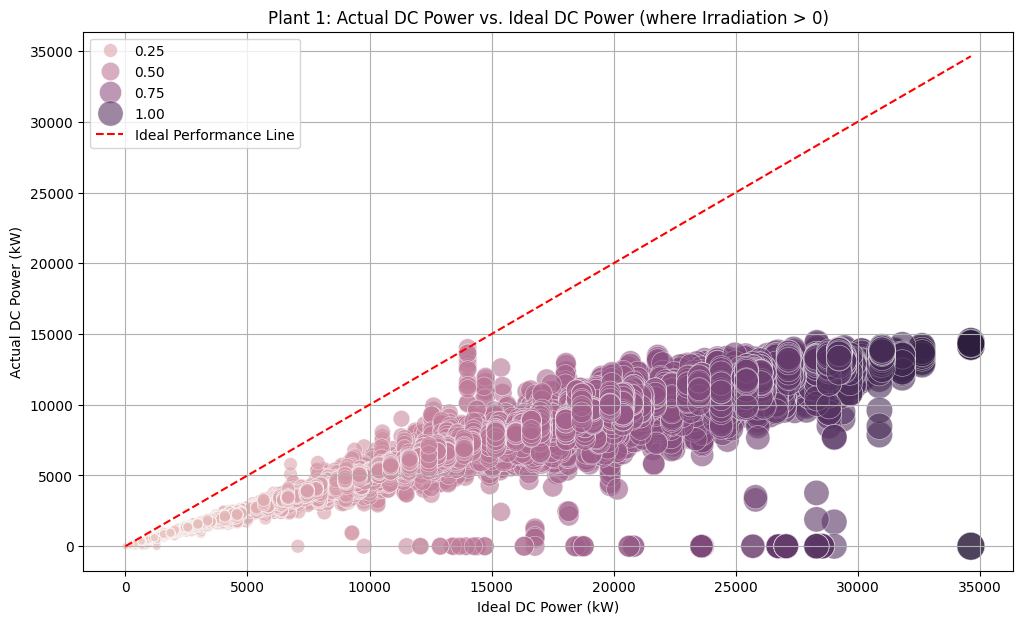

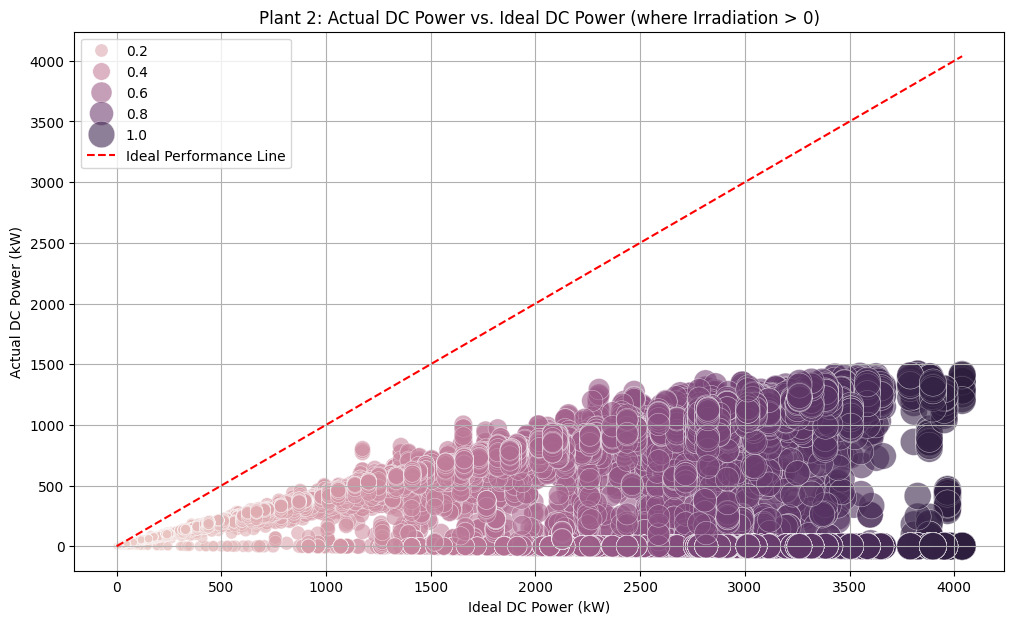

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data to only include periods with IRRADIATION > 0 for meaningful comparison
plot_data_plant1 = merged_plant1_data[merged_plant1_data['IRRADIATION'] > 0].copy()
plot_data_plant2 = merged_plant2_data[merged_plant2_data['IRRADIATION'] > 0].copy()

# --- Plot for Plant 1: DC_POWER vs IDEAL_DC_POWER ---
if not plot_data_plant1.empty:
    plt.figure(figsize=(12, 7))
    sns.scatterplot(x='IDEAL_DC_POWER', y='DC_POWER', data=plot_data_plant1, alpha=0.6, hue='IRRADIATION', size='IRRADIATION', sizes=(20, 400), legend='brief')
    plt.plot([plot_data_plant1['IDEAL_DC_POWER'].min(), plot_data_plant1['IDEAL_DC_POWER'].max()],
             [plot_data_plant1['IDEAL_DC_POWER'].min(), plot_data_plant1['IDEAL_DC_POWER'].max()],
             color='red', linestyle='--', label='Ideal Performance Line') # Y=X line
    plt.title('Plant 1: Actual DC Power vs. Ideal DC Power (where Irradiation > 0)')
    plt.xlabel('Ideal DC Power (kW)')
    plt.ylabel('Actual DC Power (kW)')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No data with positive irradiation for Plant 1 to plot Actual vs. Ideal DC Power.")

# --- Plot for Plant 2: DC_POWER vs IDEAL_DC_POWER ---
if not plot_data_plant2.empty:
    plt.figure(figsize=(12, 7))
    sns.scatterplot(x='IDEAL_DC_POWER', y='DC_POWER', data=plot_data_plant2, alpha=0.6, hue='IRRADIATION', size='IRRADIATION', sizes=(20, 400), legend='brief')
    plt.plot([plot_data_plant2['IDEAL_DC_POWER'].min(), plot_data_plant2['IDEAL_DC_POWER'].max()],
             [plot_data_plant2['IDEAL_DC_POWER'].min(), plot_data_plant2['IDEAL_DC_POWER'].max()],
             color='red', linestyle='--', label='Ideal Performance Line') # Y=X line
    plt.title('Plant 2: Actual DC Power vs. Ideal DC Power (where Irradiation > 0)')
    plt.xlabel('Ideal DC Power (kW)')
    plt.ylabel('Actual DC Power (kW)')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No data with positive irradiation for Plant 2 to plot Actual vs. Ideal DC Power.")

### Interpretation of Efficiency Results

*   **Inverter Efficiency**: This metric tells us how efficiently the DC power generated by the solar panels is converted into AC power. A high inverter efficiency (close to 1.0 or 100%) is desirable, indicating minimal energy loss during the conversion process.
*   The summary statistics (mean, std, min, max) provide an overview of the typical efficiency, its variability, and the range of observed values when the plant is actively generating power (DC_POWER > 0).
*   Differences in efficiency between Plant 1 and Plant 2 could be due to various factors, including different inverter models, environmental conditions, or maintenance practices.

### Time Series Analysis: Ambient Temperature, Module Temperature, DC Power, and AC Power

In [ ]:
# --- Plot Time Series for Plant 1 ---

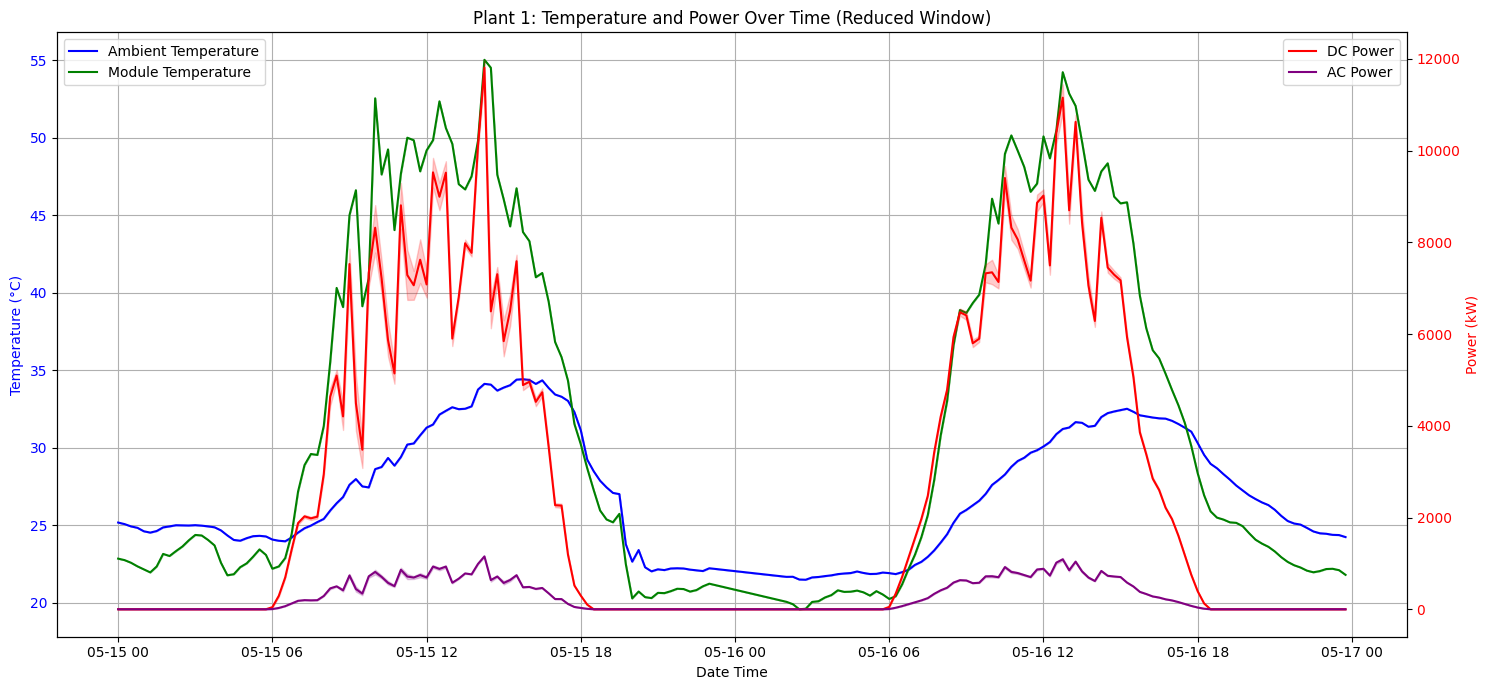

In [ ]:
if not merged_power_weather_plant1.empty:
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Plot Temperatures on the primary Y-axis (ax1)
    sns.lineplot(x='DATE_TIME', y='AMBIENT_TEMPERATURE', data=merged_power_weather_plant1, ax=ax1, label='Ambient Temperature', color='blue')
    sns.lineplot(x='DATE_TIME', y='MODULE_TEMPERATURE', data=merged_power_weather_plant1, ax=ax1, label='Module Temperature', color='green')

    ax1.set_xlabel('Date Time')
    ax1.set_ylabel('Temperature (°C)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # Create a secondary Y-axis for Power (ax2)
    ax2 = ax1.twinx()
    sns.lineplot(x='DATE_TIME', y='DC_POWER', data=merged_power_weather_plant1, ax=ax2, label='DC Power', color='red')
    sns.lineplot(x='DATE_TIME', y='AC_POWER', data=merged_power_weather_plant1, ax=ax2, label='AC Power', color='purple')

    ax2.set_ylabel('Power (kW)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    plt.title('Plant 1: Temperature and Power Over Time (Reduced Window)')
    fig.tight_layout()
    plt.show()
else:
    print("Plant 1 merged power and weather data is empty, cannot plot time series.")

In [ ]:
# --- Plot Time Series for Plant 2 ---

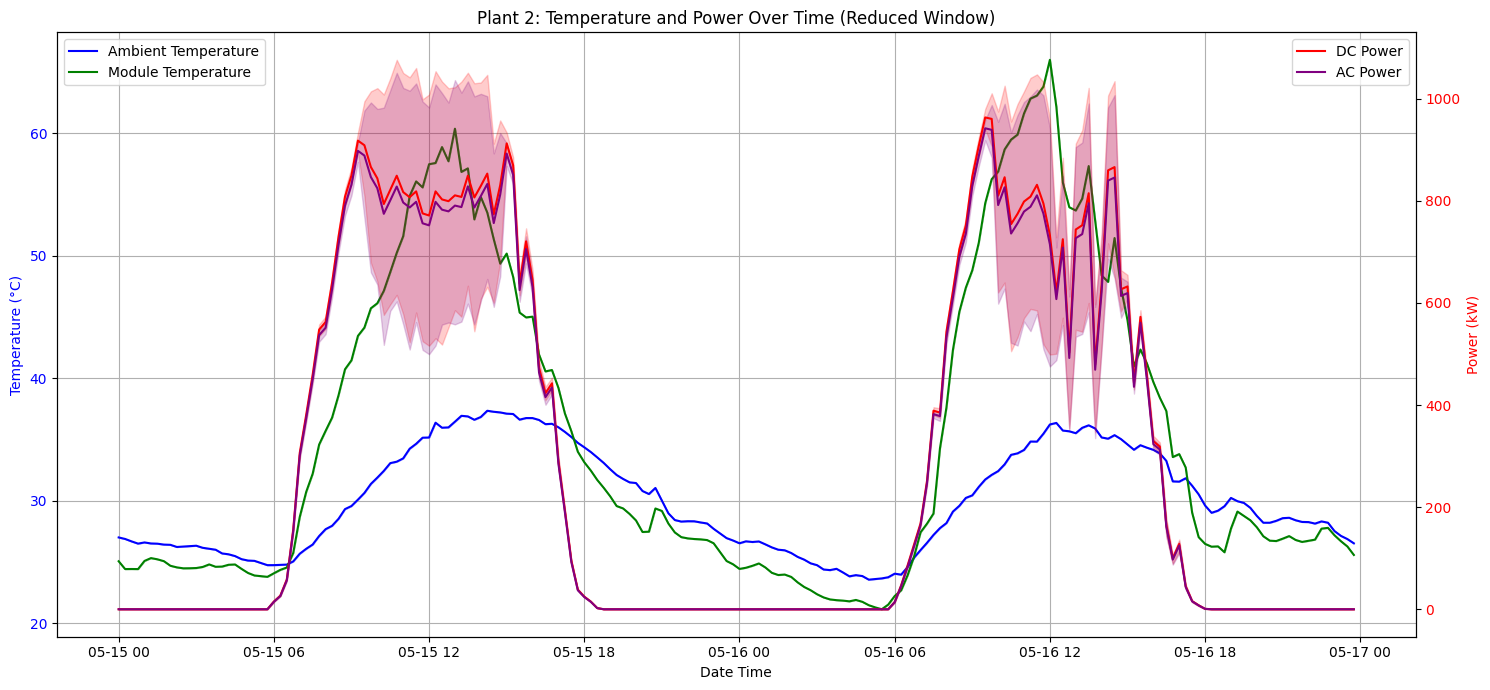

In [ ]:
if not merged_power_weather_plant2.empty:
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Plot Temperatures on the primary Y-axis (ax1)
    sns.lineplot(x='DATE_TIME', y='AMBIENT_TEMPERATURE', data=merged_power_weather_plant2, ax=ax1, label='Ambient Temperature', color='blue')
    sns.lineplot(x='DATE_TIME', y='MODULE_TEMPERATURE', data=merged_power_weather_plant2, ax=ax1, label='Module Temperature', color='green')

    ax1.set_xlabel('Date Time')
    ax1.set_ylabel('Temperature (°C)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # Create a secondary Y-axis for Power (ax2)
    ax2 = ax1.twinx()
    sns.lineplot(x='DATE_TIME', y='DC_POWER', data=merged_power_weather_plant2, ax=ax2, label='DC Power', color='red')
    sns.lineplot(x='DATE_TIME', y='AC_POWER', data=merged_power_weather_plant2, ax=ax2, label='AC Power', color='purple')

    ax2.set_ylabel('Power (kW)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    plt.title('Plant 2: Temperature and Power Over Time (Reduced Window)')
    fig.tight_layout()
    plt.show()
else:
    print("Plant 2 merged power and weather data is empty, cannot plot time series.")

### Time Series Analysis: Irradiation vs. DC Power and AC Power

### Predictive Modeling: Linear Regression for Power Output

We will now build a linear regression model to predict `DC_POWER` based on environmental factors like `IRRADIATION`, `AMBIENT_TEMPERATURE`, and `MODULE_TEMPERATURE`. This will help us understand the relationships between these variables and quantify their impact on power generation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prepare Data for Plant 1 Model ---
print("\n--- Preparing Data for Plant 1 Linear Regression Model ---")
# Define features (X) and target (y) for Plant 1
X_plant1 = merged_plant1_data[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
y_plant1 = merged_plant1_data['DC_POWER']

# Drop rows with any NaN values that might have been introduced (though cleaning was done, good practice)
X_plant1.dropna(inplace=True)
y_plant1 = y_plant1[X_plant1.index] # Align y with X after dropping NaNs

print(f"Plant 1: Features shape {X_plant1.shape}, Target shape {y_plant1.shape}")

# Split data into training and testing sets for Plant 1
X_train_plant1, X_test_plant1, y_train_plant1, y_test_plant1 = train_test_split(X_plant1, y_plant1, test_size=0.2, random_state=42)
print(f"Plant 1: Training set size: {len(X_train_plant1)}, Test set size: {len(X_test_plant1)}")

# --- Prepare Data for Plant 2 Model ---
print("\n--- Preparing Data for Plant 2 Linear Regression Model ---")
# Define features (X) and target (y) for Plant 2
X_plant2 = merged_plant2_data[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
y_plant2 = merged_plant2_data['DC_POWER']

# Drop rows with any NaN values
X_plant2.dropna(inplace=True)
y_plant2 = y_plant2[X_plant2.index] # Align y with X after dropping NaNs

print(f"Plant 2: Features shape {X_plant2.shape}, Target shape {y_plant2.shape}")

# Split data into training and testing sets for Plant 2
X_train_plant2, X_test_plant2, y_train_plant2, y_test_plant2 = train_test_split(X_plant2, y_plant2, test_size=0.2, random_state=42)
print(f"Plant 2: Training set size: {len(X_train_plant2)}, Test set size: {len(X_test_plant2)}")


--- Preparing Data for Plant 1 Linear Regression Model ---
Plant 1: Features shape (68774, 3), Target shape (68774,)
Plant 1: Training set size: 55019, Test set size: 13755

--- Preparing Data for Plant 2 Linear Regression Model ---
Plant 2: Features shape (67698, 3), Target shape (67698,)
Plant 2: Training set size: 54158, Test set size: 13540


/tmp/ipykernel_2833/3057207190.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_plant1.dropna(inplace=True)
/tmp/ipykernel_2833/3057207190.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_plant2.dropna(inplace=True)


### Train and Evaluate Linear Regression Models


--- Training and Evaluating Linear Regression Model for Plant 1 ---
Plant 1 - Mean Absolute Error (MAE): 266.37
Plant 1 - Mean Squared Error (MSE): 321488.48
Plant 1 - Root Mean Squared Error (RMSE): 567.00
Plant 1 - R-squared: 0.9801


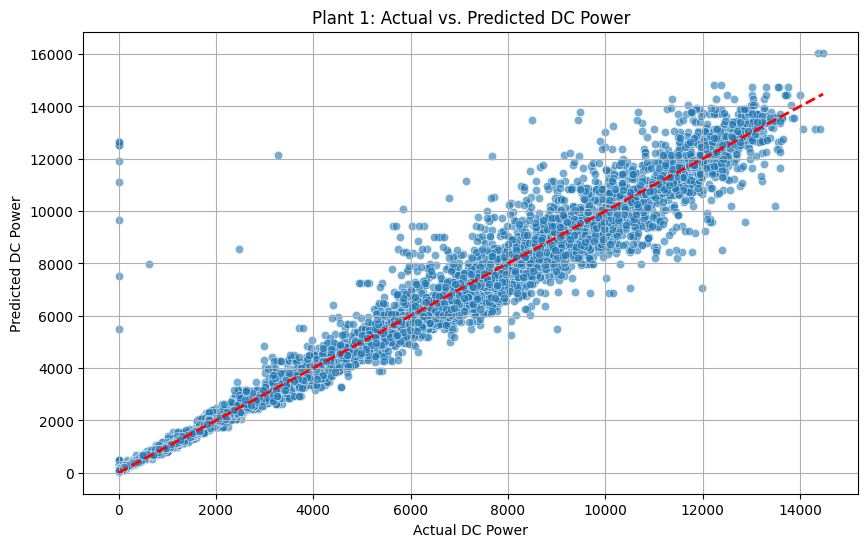


--- Training and Evaluating Linear Regression Model for Plant 2 ---
Plant 2 - Mean Absolute Error (MAE): 127.76
Plant 2 - Mean Squared Error (MSE): 52417.76
Plant 2 - Root Mean Squared Error (RMSE): 228.95
Plant 2 - R-squared: 0.6160


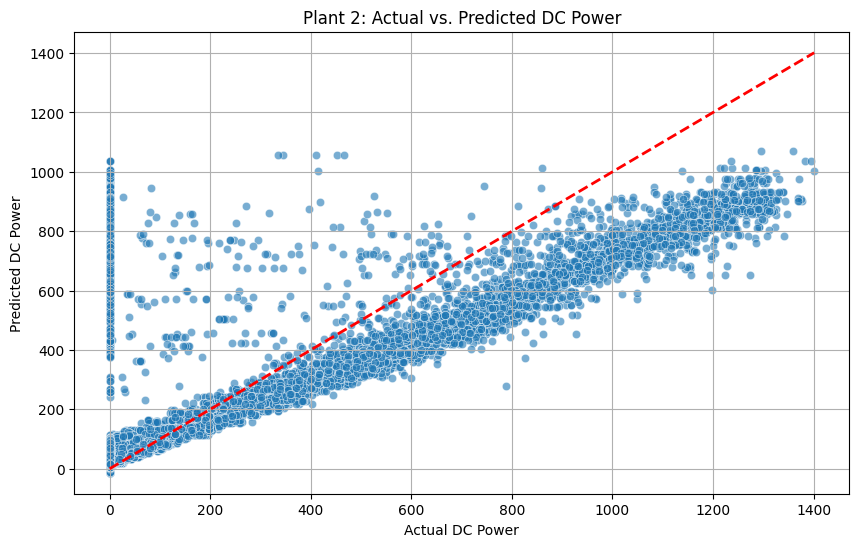

In [ ]:
# --- Train and Evaluate Model for Plant 1 ---
print("\n--- Training and Evaluating Linear Regression Model for Plant 1 ---")
model_plant1 = LinearRegression()
model_plant1.fit(X_train_plant1, y_train_plant1)

y_pred_plant1 = model_plant1.predict(X_test_plant1)

mae_plant1 = mean_absolute_error(y_test_plant1, y_pred_plant1)
mse_plant1 = mean_squared_error(y_test_plant1, y_pred_plant1)
rmse_plant1 = np.sqrt(mse_plant1)
r2_plant1 = r2_score(y_test_plant1, y_pred_plant1)

print(f"Plant 1 - Mean Absolute Error (MAE): {mae_plant1:.2f}")
print(f"Plant 1 - Mean Squared Error (MSE): {mse_plant1:.2f}")
print(f"Plant 1 - Root Mean Squared Error (RMSE): {rmse_plant1:.2f}")
print(f"Plant 1 - R-squared: {r2_plant1:.4f}")

# Plotting predictions vs actual for Plant 1
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_plant1, y=y_pred_plant1, alpha=0.6)
plt.plot([y_test_plant1.min(), y_test_plant1.max()], [y_test_plant1.min(), y_test_plant1.max()], 'r--', lw=2)
plt.title('Plant 1: Actual vs. Predicted DC Power')
plt.xlabel('Actual DC Power')
plt.ylabel('Predicted DC Power')
plt.grid(True)
plt.show()

# --- Train and Evaluate Model for Plant 2 ---
print("\n--- Training and Evaluating Linear Regression Model for Plant 2 ---")
model_plant2 = LinearRegression()
model_plant2.fit(X_train_plant2, y_train_plant2)

y_pred_plant2 = model_plant2.predict(X_test_plant2)

mae_plant2 = mean_absolute_error(y_test_plant2, y_pred_plant2)
mse_plant2 = mean_squared_error(y_test_plant2, y_pred_plant2)
rmse_plant2 = np.sqrt(mse_plant2)
r2_plant2 = r2_score(y_test_plant2, y_pred_plant2)

print(f"Plant 2 - Mean Absolute Error (MAE): {mae_plant2:.2f}")
print(f"Plant 2 - Mean Squared Error (MSE): {mse_plant2:.2f}")
print(f"Plant 2 - Root Mean Squared Error (RMSE): {rmse_plant2:.2f}")
print(f"Plant 2 - R-squared: {r2_plant2:.4f}")

# Plotting predictions vs actual for Plant 2
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_plant2, y=y_pred_plant2, alpha=0.6)
plt.plot([y_test_plant2.min(), y_test_plant2.max()], [y_test_plant2.min(), y_test_plant2.max()], 'r--', lw=2)
plt.title('Plant 2: Actual vs. Predicted DC Power')
plt.xlabel('Actual DC Power')
plt.ylabel('Predicted DC Power')
plt.grid(True)
plt.show()

### Interpretation of Linear Regression Results

The evaluation metrics provide insights into how well the linear regression models perform for each plant:

*   **R-squared (R²)**: Indicates the proportion of the variance in the dependent variable (DC Power) that is predictable from the independent variables (Irradiation, Ambient Temperature, Module Temperature). A higher R² value (closer to 1) suggests a better fit.
*   **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual observations. It gives a direct measure of the average magnitude of the errors.
*   **Mean Squared Error (MSE)**: The average of the squared differences between predictions and actual observations. It penalizes larger errors more heavily.
*   **Root Mean Squared Error (RMSE)**: The square root of the MSE. It has the same units as the target variable, making it easier to interpret than MSE.

### Interpretation of Model Coefficients

The coefficients of the linear regression model indicate the weight or importance of each feature in predicting the target variable (`DC_POWER`). A positive coefficient suggests that as the feature value increases, the `DC_POWER` is expected to increase, while a negative coefficient suggests the opposite. The magnitude of the coefficient indicates the strength of this relationship.

In [ ]:
import pandas as pd

# Get feature names
feature_names = X_plant1.columns

# --- Coefficients for Plant 1 Model ---
print("\n--- Linear Regression Coefficients for Plant 1 ---")
coefficients_plant1 = pd.DataFrame({'Feature': feature_names, 'Coefficient': model_plant1.coef_})
print(coefficients_plant1)

# --- Coefficients for Plant 2 Model ---
print(
"\n--- Linear Regression Coefficients for Plant 2 ---")
coefficients_plant2 = pd.DataFrame({'Feature': feature_names, 'Coefficient': model_plant2.coef_})
print(coefficients_plant2)


--- Linear Regression Coefficients for Plant 1 ---
               Feature   Coefficient
0          IRRADIATION  12534.703639
1  AMBIENT_TEMPERATURE     -3.340815
2   MODULE_TEMPERATURE     18.165152

--- Linear Regression Coefficients for Plant 2 ---
               Feature  Coefficient
0          IRRADIATION  1074.002281
1  AMBIENT_TEMPERATURE    14.916042
2   MODULE_TEMPERATURE    -7.833022


### Summary of Predictive Modeling

For **Plant 1**, the linear regression model demonstrates a very strong predictive capability for `DC_POWER` (R² = 0.9801) using `IRRADIATION`, `AMBIENT_TEMPERATURE`, and `MODULE_TEMPERATURE` as features. The coefficients show a significant positive relationship between `IRRADIATION` and `DC_POWER`, which is expected. `MODULE_TEMPERATURE` also shows a positive influence, while `AMBIENT_TEMPERATURE` has a smaller, though still positive, impact.

For **Plant 2**, the model's performance is moderate (R² = 0.6160). While the same features are used, they explain a much smaller portion of the variance in `DC_POWER` compared to Plant 1. This suggests that other unmodeled factors might be more influential for Plant 2, or the relationship between these features and `DC_POWER` is more complex and less linear. Similar to Plant 1, `IRRADIATION` and `MODULE_TEMPERATURE` are the strongest positive predictors. The difference in model performance between the two plants could be due to variations in plant design, sensor accuracy, environmental specifics, or operational characteristics.

Overall, the models confirm the crucial role of `IRRADIATION` and `MODULE_TEMPERATURE` in predicting solar power output, with Plant 1's data exhibiting a more linear and predictable relationship. Further investigation could involve more advanced regression techniques or additional features to improve Plant 2's model.

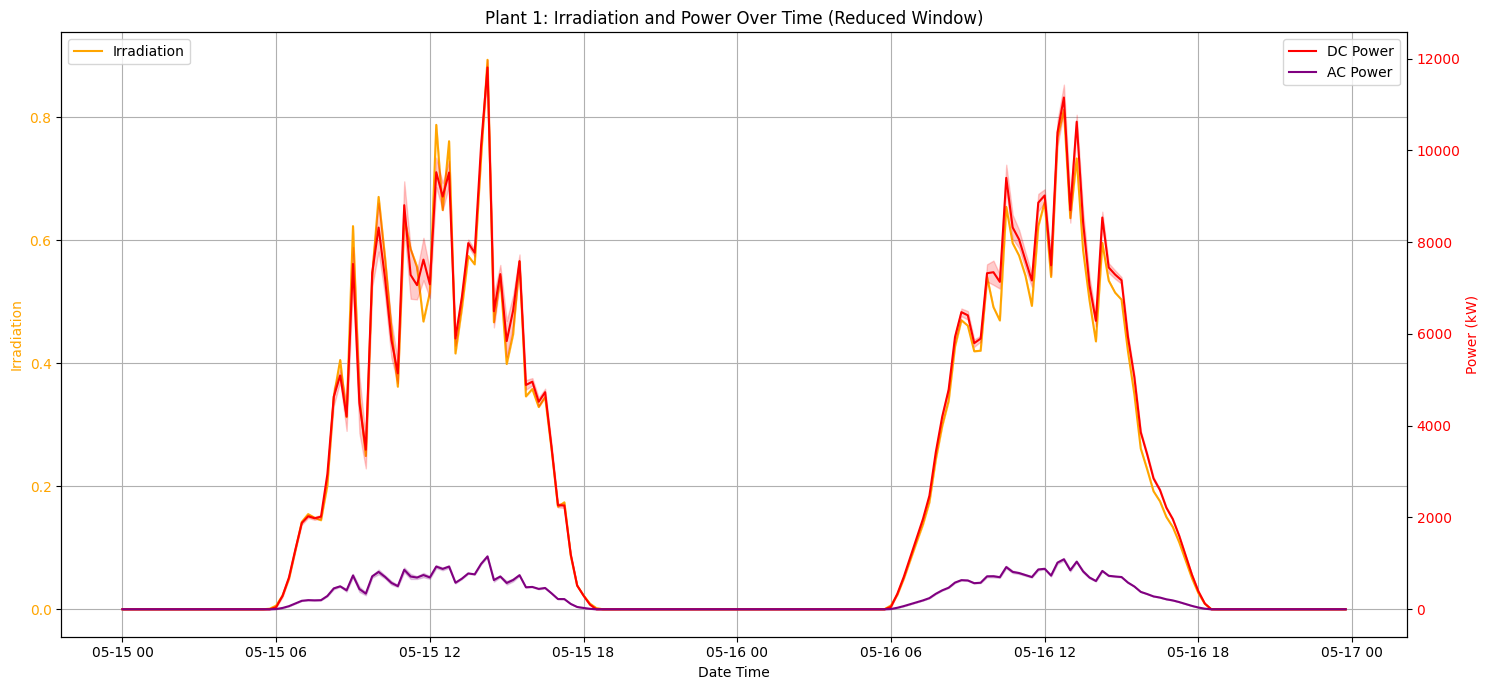

In [ ]:
# --- Plot Time Series for Plant 1 (Irradiation vs Power) ---
if not merged_power_weather_plant1.empty:
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Plot Irradiation on the primary Y-axis (ax1)
    sns.lineplot(x='DATE_TIME', y='IRRADIATION', data=merged_power_weather_plant1, ax=ax1, label='Irradiation', color='orange')

    ax1.set_xlabel('Date Time')
    ax1.set_ylabel('Irradiation', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # Create a secondary Y-axis for Power (ax2)
    ax2 = ax1.twinx()
    sns.lineplot(x='DATE_TIME', y='DC_POWER', data=merged_power_weather_plant1, ax=ax2, label='DC Power', color='red')
    sns.lineplot(x='DATE_TIME', y='AC_POWER', data=merged_power_weather_plant1, ax=ax2, label='AC Power', color='purple')

    ax2.set_ylabel('Power (kW)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    plt.title('Plant 1: Irradiation and Power Over Time (Reduced Window)')
    fig.tight_layout()
    plt.show()
else:
    print("Plant 1 merged power and weather data is empty, cannot plot irradiation time series.")

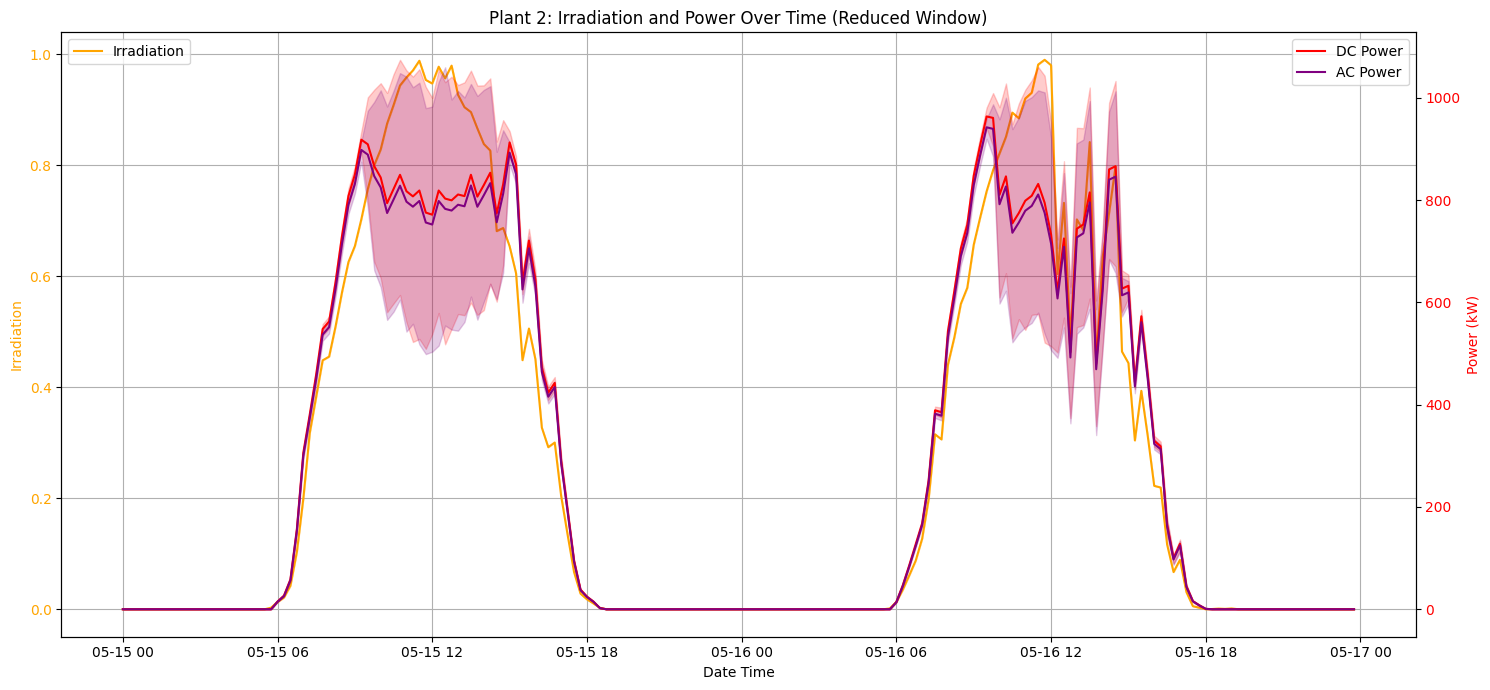

In [ ]:
# --- Plot Time Series for Plant 2 (Irradiation vs Power) ---
if not merged_power_weather_plant2.empty:
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Plot Irradiation on the primary Y-axis (ax1)
    sns.lineplot(x='DATE_TIME', y='IRRADIATION', data=merged_power_weather_plant2, ax=ax1, label='Irradiation', color='orange')

    ax1.set_xlabel('Date Time')
    ax1.set_ylabel('Irradiation', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # Create a secondary Y-axis for Power (ax2)
    ax2 = ax1.twinx()
    sns.lineplot(x='DATE_TIME', y='DC_POWER', data=merged_power_weather_plant2, ax=ax2, label='DC Power', color='red')
    sns.lineplot(x='DATE_TIME', y='AC_POWER', data=merged_power_weather_plant2, ax=ax2, label='AC Power', color='purple')

    ax2.set_ylabel('Power (kW)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    plt.title('Plant 2: Irradiation and Power Over Time (Reduced Window)')
    fig.tight_layout()
    plt.show()
else:
    print("Plant 2 merged power and weather data is empty, cannot plot irradiation time series.")

In [ ]:
# Compare the correlations for Ambient Temp vs Total Yield (from previous step)

# Check if corr_plant1_ambient_total and corr_plant2_ambient_total are available
if 'corr_plant1_ambient_total' in locals() and 'corr_plant2_ambient_total' in locals():
    print(f"\nComparison of Ambient Temperature vs Total Yield Correlations:")
    print(f"Plant 1: {corr_plant1_ambient_total:.4f}")
    print(f"Plant 2: {corr_plant2_ambient_total:.4f}")

    if abs(corr_plant1_ambient_total - corr_plant2_ambient_total) < 0.01: # Check for approximate equality
        print("The correlations between ambient temperature and total yield are similar for Plant 1 and Plant 2.")
    else:
        print("The correlations between ambient temperature and total yield are different for Plant 1 and Plant 2.")
else:
    print("Ambient Temperature vs Total Yield correlations were not computed. Please run the previous cell.")

# Compare the correlations for Module Temp vs Power Generation
if 'corr_plant1_module_dc' in locals() and 'corr_plant1_module_ac' in locals() and \
   'corr_plant2_module_dc' in locals() and 'corr_plant2_module_ac' in locals():
    print(f"\nComparison of Module Temperature vs DC Power Correlations:")
    print(f"Plant 1: {corr_plant1_module_dc:.4f}")
    print(f"Plant 2: {corr_plant2_module_dc:.4f}")

    print(f"\nComparison of Module Temperature vs AC Power Correlations:")
    print(f"Plant 1: {corr_plant1_module_ac:.4f}")
    print(f"Plant 2: {corr_plant2_module_ac:.4f}")

    # Determine if correlations are direct or inverse
    print("\n--- Analysis of Module Temperature vs Power Generation Correlations ---")
    print(f"For Plant 1: Module Temperature vs DC Power is {'direct (positive)' if corr_plant1_module_dc > 0 else 'inverse (negative)' if corr_plant1_module_dc < 0 else 'negligible'}.")
    print(f"For Plant 1: Module Temperature vs AC Power is {'direct (positive)' if corr_plant1_module_ac > 0 else 'inverse (negative)' if corr_plant1_module_ac < 0 else 'negligible'}.")
    print(f"For Plant 2: Module Temperature vs DC Power is {'direct (positive)' if corr_plant2_module_dc > 0 else 'inverse (negative)' if corr_plant2_module_dc < 0 else 'negligible'}.")
    print(f"For Plant 2: Module Temperature vs AC Power is {'direct (positive)' if corr_plant2_module_ac > 0 else 'inverse (negative)' if corr_plant2_module_ac < 0 else 'negligible'}.")

else:
    print("Module Temperature vs Power Generation correlations were not computed. Please run the previous cell.")

# Compare the correlations for Irradiation vs Power Generation
if 'corr_plant1_irradiation_dc' in locals() and 'corr_plant1_irradiation_ac' in locals() and \
   'corr_plant2_irradiation_dc' in locals() and 'corr_plant2_irradiation_ac' in locals():
    print(f"\nComparison of Irradiation vs DC Power Correlations:")
    print(f"Plant 1: {corr_plant1_irradiation_dc:.4f}")
    print(f"Plant 2: {corr_plant2_irradiation_dc:.4f}")

    print(f"\nComparison of Irradiation vs AC Power Correlations:")
    print(f"Plant 1: {corr_plant1_irradiation_ac:.4f}")
    print(f"Plant 2: {corr_plant2_irradiation_ac:.4f}")

    # Determine if correlations are direct or inverse
    print("\n--- Analysis of Irradiation vs Power Generation Correlations ---")
    print(f"For Plant 1: Irradiation vs DC Power is {'direct (positive)' if corr_plant1_irradiation_dc > 0 else 'inverse (negative)' if corr_plant1_irradiation_dc < 0 else 'negligible'}.")
    print(f"For Plant 1: Irradiation vs AC Power is {'direct (positive)' if corr_plant1_irradiation_ac > 0 else 'inverse (negative)' if corr_plant1_irradiation_ac < 0 else 'negligible'}.")
    print(f"For Plant 2: Irradiation vs DC Power is {'direct (positive)' if corr_plant2_irradiation_dc > 0 else 'inverse (negative)' if corr_plant2_irradiation_dc < 0 else 'negligible'}.")
    print(f"For Plant 2: Irradiation vs AC Power is {'direct (positive)' if corr_plant2_irradiation_ac > 0 else 'inverse (negative)' if corr_plant2_irradiation_ac < 0 else 'negligible'}.")

else:
    print("Irradiation vs Power Generation correlations were not computed. Please run the previous cell.")

# Compare the correlations for Ambient Temp vs Power Generation
if 'corr_plant1_ambient_dc' in locals() and 'corr_plant1_ambient_ac' in locals() and \
   'corr_plant2_ambient_dc' in locals() and 'corr_plant2_ambient_ac' in locals():
    print(f"\nComparison of Ambient Temperature vs DC Power Correlations:")
    print(f"Plant 1: {corr_plant1_ambient_dc:.4f}")
    print(f"Plant 2: {corr_plant2_ambient_dc:.4f}")

    print(f"\nComparison of Ambient Temperature vs AC Power Correlations:")
    print(f"Plant 1: {corr_plant1_ambient_ac:.4f}")
    print(f"Plant 2: {corr_plant2_ambient_ac:.4f}")

    # Determine if correlations are direct or inverse
    print("\n--- Analysis of Ambient Temperature vs Power Generation Correlations ---")
    print(f"For Plant 1: Ambient Temperature vs DC Power is {'direct (positive)' if corr_plant1_ambient_dc > 0 else 'inverse (negative)' if corr_plant1_ambient_dc < 0 else 'negligible'}.")
    print(f"For Plant 1: Ambient Temperature vs AC Power is {'direct (positive)' if corr_plant1_ambient_ac > 0 else 'inverse (negative)' if corr_plant1_ambient_ac < 0 else 'negligible'}.")
    print(f"For Plant 2: Ambient Temperature vs DC Power is {'direct (positive)' if corr_plant2_ambient_dc > 0 else 'inverse (negative)' if corr_plant2_ambient_dc < 0 else 'negligible'}.")
    print(f"For Plant 2: Ambient Temperature vs AC Power is {'direct (positive)' if corr_plant2_ambient_ac > 0 else 'inverse (negative)' if corr_plant2_ambient_ac < 0 else 'negligible'}.")

else:
    print("Ambient Temperature vs Power Generation correlations were not computed. Please run the previous cell.")


Comparison of Ambient Temperature vs Total Yield Correlations:
Plant 1: -0.0362
Plant 2: 0.0028
The correlations between ambient temperature and total yield are different for Plant 1 and Plant 2.

Comparison of Module Temperature vs DC Power Correlations:
Plant 1: 0.9548
Plant 2: 0.7497

Comparison of Module Temperature vs AC Power Correlations:
Plant 1: 0.9549
Plant 2: 0.7496

--- Analysis of Module Temperature vs Power Generation Correlations ---
For Plant 1: Module Temperature vs DC Power is direct (positive).
For Plant 1: Module Temperature vs AC Power is direct (positive).
For Plant 2: Module Temperature vs DC Power is direct (positive).
For Plant 2: Module Temperature vs AC Power is direct (positive).

Comparison of Irradiation vs DC Power Correlations:
Plant 1: 0.9894
Plant 2: 0.7810

Comparison of Irradiation vs AC Power Correlations:
Plant 1: 0.9893
Plant 2: 0.7809

--- Analysis of Irradiation vs Power Generation Correlations ---
For Plant 1: Irradiation vs DC Power is direct